<div style="border:solid Green 2px; border-radius: 10px;  padding: 40px">
<b>Привет, Андрей!👋</b>
    
Меня зовут Зуева Юлия, можно просто Юля 😏 Я буду ревьюером твоего проекта. Предлагаю обращаться на "ты", но если это неудобно, пожалуйста, скажи об этом! 
    
Моя основная цель - помочь тебе стать компетентным Data Scientist'ом: вместе преодолеть трудности и еще больше развить твои сильные навыки 💪 В твоей работе я оставила комментарии, которые должны в этом помочь. Для твоего удобства комментарии раскрашены разными цветами: 
<br/>
<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> В случае корректного решения (или отдельных его моментов). На такие решения можно опираться в будущем.
</div>
<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> Если есть возможность как-либо улучшить решение. Ты можешь учесть эти комментарии при доработке проекта, однако для зачета это не обязательно.
</div>
<div style="border-radius: 10px" class="alert alert-block alert-danger">
<b>Нужно доработать ❌:</b> Если решение требует внесения правок. Проект не может быть принят, если остались не отработанные комментарии данного типа.
</div>

Чтобы наша с тобой работа была еще эффективнее, ты точно так же можешь оставлять комментарии и задавать мне вопросы. Для таких случаев, пожалуйста, выбери собственное оформление комментариев, которое будет отличаться от моего, чтобы не создавалась путаница. По этой же причине попрошу тебя не удалять и не изменять мои комментарии. Все это позволит лучше ориентироваться в нашем с тобой диалоге, а повторную проверку (в случае ее необходимости) выполнять оперативнее 🚀
    
Не спеши расстраиваться, если что-то не удалось с первого раза. Вместе мы обязательно разберемся со всеми трудностями! 🤓


# Модель поведенческого скоринга для выявления риска просрочек по платежам

## Цели и задачи
### Цель:
Разработать модель, которая будет предсказывать наличие и вероятность риска просрочки платежа по кредиту в 90 дней на основании данных за выбранный месяц. 

### Постановка задачи в терминах машинного обучения
- Тип задачи машинного обучения: бинарная классификация на основе данных с временной структурой.
- Целевая переменная - идентификатор класса (0/1), факт наличия просрочки на 90 дней по платежам в горизонте прогнозирования 12 месяцев.
- Модели машинного обучения - логистическая регрессия, случайный лес.
- Методы корректировки дисбаланса классов - оверсэмплинг, андерсэмплинг, модификация лосса (взвешивание).
- Необходимо использовать кросс-валидацию данных на основе временных рядов для оценки качества моделей. Количество фолдов - 3.
- Основные метрики - Approval Rate, Default Rate, Missed Defaults Rate. Вспомогательные метрики - Accuracy, ROC-AUC.     
- Требования к значениям метрик:
    - Approval rate не менее 65%.
    - Default rate не более 2%.
    - Missed defaults rate не более 4%.
- Для подбора оптимального набора гиперпараметров следует использовать байесовскую оптимизацию.
- Вероятности принадлежности к классам, возвращаемые моделью, должны быть откалиброваны.
- Необходимо обеспечить воспроизводимость результатов при помощи указания фиксированного значения `random_state`.

### Задачи:
1. Загрузка таблиц датасета.
2. Объединение таблиц в единый датасет, расчет таргета.
4. Исследовательский анализ данных.
5. Предобработка данных для машинного обучения, добавление новых признаков.
6. Обучение базовых моделей логистической регрессии и случайного леса с параметрами по умолчанию.
7. Обучение базовых моделей логистической регрессии и случайного леса с параметрами по умолчанию и с использованием методов балансировки классов.
8. Получение и сравнение оценок базовых моделей на кросс-валидации.
9. Подбор гиперпараметров для модели случайного леса при помощи библиотеки Optuna с использование кросс-валидации.
7. Обучение модели случайного леса с лучшими гиперпараметрами и стратегией балансировки классов.
8. Калибровка обученной модели, построение графиков калибровки.
9. Исследование стабильности метрик на калибровочной и тестовой выборках.
10. Оценка важности признаков.
11. Формулировка выводов и рекомендаций по дальнейшему усовершенствованию модели.


### Описание данных
В моделях поведенческого скоринга учитываются разные типы признаков:

- Социально-демографические факторы.
- Финансовое поведение клиента, включая траты по MCC-кодам.
- Источники поступлений денежных средств.
- Регулярность поступлений денежных средств.
- Динамика кредитного рейтинга.
- Наличие ипотечных и семейных обязательств.
- Макроэкономические факторы.

**Таблица 1. Данные о просрочке платежа (loan_payment_credit)**

Содержит столбцы:

- `ID` — идентификатор клиента.
- `дата_начала_периода` — дата начала периода просрочки.
- `просрочка_дней` — длительность просрочки в днях.

**Таблица 2. Месячные транзакции клиента (transactions)**

Таблица содержит информацию о тратах клиента по MCC-кодам.

- `ID` — идентификатор клиента.
- `date` — календарная дата по месяцам.
- `MCC_5300` — помесячные траты клиента по коду 5300.
- `MCC_5814` — помесячные траты клиента по коду 5814.
- `MCC_5812` — помесячные траты клиента по коду 5812.
- `MCC_5411` — помесячные траты клиента по коду 5411.
- `MCC_3990` — помесячные траты клиента по коду 3990.
- `MCC_5722` — помесячные траты клиента по коду 5722.
- `MCC_4900` — помесячные траты клиента по коду 4900.
- `MCC_другое` — помесячные траты клиента по остальным кодам.

Расшифровка кодов:

|**MCC-код**|**Категория**|**Расшифровка и примеры**|
|---|---|---|
|5300|Оптовики|Маркетплейсы: Ozon, Lamoda, Wildberries и другие.|
|5814|Фастфуд|Рестораны быстрого питания: «Вкусно — и точка», «Бургер Кинг» и другие.|
|5812|Места общественного питания, рестораны|Столовые и кафе: «Якитория», «Хлеб Насущный» и другие.|
|5411|Бакалейные магазины, супермаркеты|Большинство продуктовых магазинов: «Пятёрочка», «Магнит» и другие.|
|3990|Экосистема Яндекса|Яндекс Афиша, Яндекс Такси, Яндекс Книги и другие сервисы.|
|5722|Бытовое оборудование|Магазины, продающие технику для дома: «М.Видео», «Ситилинк» и другие.|
|4900|Жилищно-коммунальные услуги|Точки, оказывающие услуги по передаче или распределению электроэнергии, газа, установке и обслуживанию систем водоснабжения, сбору и утилизации отходов.|
|MCC_другое|Остальные категории||

**Таблица 3. Описание клиента на момент регистрации в банке (client_description)**

Содержит столбцы:

- `ID` — идентификатор клиента.
- `возраст` — возраст клиента.
- `семейное_положение` — семейное положение клиента. Три состояния: `разведённые`, `есть семья`, `нет семьи`.
- `наличие_иждивенцев` — есть ли у клиента лица на финансовом попечении: `1` — да, `0` — нет.
- `дата_регистрации` — календарная дата начала взаимоотношений банка и клиента.

**Таблица 4. Описание кредита (credit_description)**

Содержит столбцы:

- `ID` — идентификатор клиента.
- `доход` — месячный доход клиента на момент взятия кредита в рублях.
- `сумма_кредита` — сумма кредита, выданного клиенту, в рублях.

**Таблица 5. Данные о наличии ипотеки (mortgage_presence)**

Содержит столбцы:

- `ID` — идентификатор клиента.
- `дата_открытия` — календарная дата, когда клиент оформил ипотеку.
- `наличие_ипотеки` — есть ли у клиента ипотека: `1` — да, `0` — нет.

**Таблица 6. Данные о кредитном рейтинге клиента (credit_rating)**

Содержит столбцы:

- `ID` — идентификатор клиента.
- `date` — календарная дата получения рейтинга из внешнего источника.
- `кредитный_рейтинг` — значение рейтинга клиента на конкретную дату.

**Таблица 7. Данные о макроэкономических показателях России (macro_data)**

Содержит столбцы:

- `date` — месяц и год, на которые актуальны указанные показатели.
- `учетная_ставка` — учётная ставка в процентах.
- `уровень_безработицы` — уровень безработицы в процентах.
- `инфляция` — инфляция в процентах.

**Таблица 8. Данные о дате проведения поведенческого скоринга (cohort_grid)**

Содержит столбцы:

- `ID` — идентификатор клиента.
- `score_date` — дата скоринга.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Вводная часть <a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
Здорово, что оформляешь вводную часть проекта. Она помогает быстро понять цель, контекст и структуру работы - это удобно и для тебя при возвращении к проекту спустя время, и для любого другого читателя, особенно если проект публикуется в портфолио или используется как пример практической работы. Полезно воспринимать такую тетрадку не просто как выполнение домашнего задания, а как полноценный исследовательский или аналитический проект. 
    
<br/>
    
<details> <summary> <span style='color:blue' > Что обычно отмечают во введении (тык) </span> </summary>

* название и краткое описание проблемы, которую хотим решить, бизнес-контекст;
* постановку задачи и формулирование цели исследования, ожидаемого результата и практической ценности;
* описание данных: источник, объем, период, основные особенности и ограничения;
* используемые подходы, инструменты или методы анализа;
* важные допущения, ограничения и особенности поставленной задачи;
* краткий план работы и основные этапы исследования.

</details>
    
По сути, вводная часть отвечает на несколько базовых вопросов: что мы делаем, зачем, с какими данными работаем, какими методами будем решать задачу и в каких условиях проводится анализ. Хорошо оформленное введение делает проект более цельным, профессиональным и значительно упрощает навигацию по работе.

</div>

<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации 💡:</b> 

Сейчас твое введение чисто техническое. Но первое, что нам важно сделать, это обозначить проблематику и, отталкиваясь от нее, поставить цель. После постановки цели - то, к чему мы должны прийти, обозначаем то, что у нас есть в распоряжении - данные.
   
</div>

## 1. Подготовка среды и загрузка данных

### 1.1. Установка библиотек

In [1]:
%pip install scikit-learn
%pip install -q --upgrade seaborn
%pip install -q --upgrade jinja2
%pip install -q phik
%pip install -q optuna
%pip install -q joblib
%pip install -q mlxtend
%pip install -q imblearn

# Сохраним версии библиотек в requirements.txt
%pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


### 1.2. Импорт необходимых библиотек

In [2]:
import os
from urllib.request import urlopen

# Библиотеки для вычислений и работы с датасетами
import pandas as pd
import numpy as np
import phik
from scipy.stats import chi2_contingency

# Библиотеки машинного обучения
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import f1_score, accuracy_score, precision_score, roc_auc_score, \
    recall_score, brier_score_loss, precision_recall_curve, confusion_matrix
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from mlxtend.evaluate.time_series import (
    GroupTimeSeriesSplit,
    plot_splits,
    print_cv_info,
    print_split_info,
) 

# Подбор гиперпараметров
import optuna

# Библиотеки для построения графиков
import seaborn as sns
import matplotlib.pyplot as plt

# Сериализация пайплайна
import joblib

# Для форматирования в HTML
from IPython.display import display, HTML, Markdown

c:\Users\astuser.PATRIARCHIA\Projects\Yandex DS\ds-yandex\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Импорты <a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
Здорово, что все необходимые библиотеки подгружаешь сразу в начале проекта! Это соответствует стандартам оформления кода <a href='https://pyplanet.ru/article/pep-0008.html'>PEP 8</a>. Такой подход позволяет сразу видеть, какое окружение необходимо для запуска проекта, избежать дублирования импортов в разных частях кода, а также облегчить отладку и переносимость проекта.

</div>

<div style="border-radius: 10px" class="alert alert-warning">
    
<b>Рекомендации💡:</b> 


* Иногда бывает полезно импортировать библиотеки одной строкой: `!pip install - q imblearn mlxtend optuna`, чтобы учитывались разу все зависимости и разрешались конфликты ве в случае их обнаружения.

    
* Подгружать необходимо только то, что действительно используется в проекте.

    
* Множественное импортирование обычно оформляют следующим образом для сохранения большей читаемости: 
    
    ```python
from sklearn.preprocessing import (
      OneHotEncoder,
      OrdinalEncoder
)
```
    
</div>


### 1.3. Загрузка данных

In [3]:
# Константы и общие настройки
RANDOM_SEED = 42

# Горизонт планирования в месяцах
PLANNING_HORIZON_MONTHS = 12

# Учитываемая просрочка в днях
DEFAULT_DURATION_DAYS = 90

pd.options.display.float_format = '{:.4f}'.format

BASE_URL = "https://code.s3.yandex.net/"

def load_dataset(file_name, **kwargs):
    try:
        if os.path.exists(file_name):
            return pd.read_csv(file_name, **kwargs)
        else:
            return pd.read_csv(BASE_URL + file_name, **kwargs)
    except:
        print("Ошибка загрузки датасета")
        raise

datasets = {}
datasets["loan_payment_credit"] = load_dataset("datasets/ds_15_loan_payment_credit.csv",
                                               parse_dates=['дата_начала_периода'])
datasets["transactions"] = load_dataset("datasets/ds_15_transactions.csv",
                                               parse_dates=['date'])
datasets["client_description"] = load_dataset("datasets/ds_15_client_description.csv",
                                               parse_dates=['дата_регистрации'])
datasets["credit_description"] = load_dataset("datasets/ds_15_credit_description.csv")
datasets["mortgage_presence"] = load_dataset("datasets/ds_15_mortgage_presence.csv",
                                               parse_dates=['дата_открытия'])
datasets["credit_rating"] = load_dataset("datasets/ds_15_credit_rating.csv",
                                               parse_dates=['date'])
datasets["macro_data"] = load_dataset("datasets/ds_15_macro_data.csv",
                                               parse_dates=['date'])
datasets["cohort_grid"] = load_dataset("datasets/ds_15_cohort_grid.csv",
                                               parse_dates=['score_date'])

for key, value in datasets.items():
    display(HTML("<h2>Таблица " + key + "</h2>"))
    display(value.info())
    display(value.head())

last_month = max(datasets['cohort_grid']['score_date'])
display(HTML(f'''<h2>Диапазон дат: </h2> с {min(datasets['cohort_grid']['score_date']):%Y-%m-%d} по
             {last_month:%Y-%m-%d}'''))

<class 'pandas.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   5500 non-null   str           
 1   дата_начала_периода  5500 non-null   datetime64[us]
 2   просрочка_дней       5500 non-null   int64         
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 129.0 KB


None

,ID,дата_начала_периода,просрочка_дней
0,IDF55109846,2014-12-01,120
1,IDF54995533,2015-06-01,121
2,IDF54964538,2018-03-01,87
3,IDF55079777,2019-09-01,109
4,IDF55093915,2017-02-01,84


<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   ID          577494 non-null  str           
 1   date        577494 non-null  datetime64[us]
 2   MCC_5300    577494 non-null  float64       
 3   MCC_5814    577494 non-null  float64       
 4   MCC_5812    577494 non-null  float64       
 5   MCC_5411    577494 non-null  float64       
 6   MCC_3990    577494 non-null  float64       
 7   MCC_5722    577494 non-null  float64       
 8   MCC_4900    577494 non-null  float64       
 9   MCC_другое  577494 non-null  float64       
dtypes: datetime64[us](1), float64(8), str(1)
memory usage: 44.1 MB


None

,ID,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
0,IDF55109846,2013-05-01,3267.5900,1282.1100,1457.9600,5711.1000,647.4300,2374.7800,4059.8600,3657.3500
1,IDF55109846,2013-06-01,3196.5800,2443.3700,1334.2000,5824.6500,1067.5500,2187.1100,4592.2600,3322.6100
2,IDF55109846,2013-07-01,3550.5400,4277.7200,1463.7500,5209.5100,1167.9500,2076.5400,3605.2500,3467.0600
3,IDF55109846,2013-08-01,3385.9800,4530.6300,1261.4000,5765.9600,986.9900,2231.7700,2209.3900,3354.4400
4,IDF55109846,2013-09-01,3214.8400,4146.6500,1405.1500,5632.1100,640.7600,2156.6700,1519.4600,4352.9000


<class 'pandas.DataFrame'>
RangeIndex: 13500 entries, 0 to 13499
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ID                  13500 non-null  str           
 1   возраст             13500 non-null  int64         
 2   семейное_положение  13500 non-null  str           
 3   наличие_иждивенцев  13500 non-null  int64         
 4   дата_регистрации    13500 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(2), str(2)
memory usage: 527.5 KB


None

,ID,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации
0,IDF55109846,41,разведённые,1,2013-05-01
1,IDF54900291,45,разведённые,1,2017-12-01
2,IDF54995533,34,разведённые,1,2013-11-01
3,IDF55065581,40,нет семьи,1,2018-08-01
4,IDF55057353,66,разведённые,0,2018-05-01


<class 'pandas.DataFrame'>
RangeIndex: 13500 entries, 0 to 13499
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   ID             13500 non-null  str  
 1   доход          13500 non-null  int64
 2   сумма_кредита  13500 non-null  int64
dtypes: int64(2), str(1)
memory usage: 316.5 KB


None

,ID,доход,сумма_кредита
0,IDF55109846,27035,1960785
1,IDF54900291,64502,3375810
2,IDF54995533,90477,401700
3,IDF55065581,133475,1952655
4,IDF55057353,51324,1107870


<class 'pandas.DataFrame'>
RangeIndex: 6609 entries, 0 to 6608
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ID               6609 non-null   str           
 1   дата_открытия    6609 non-null   datetime64[us]
 2   наличие_ипотеки  6609 non-null   int64         
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 155.0 KB


None

,ID,дата_открытия,наличие_ипотеки
0,IDF54896351,2013-03-01,1
1,IDF54896367,2018-01-01,1
2,IDF54896414,2018-02-01,1
3,IDF54896494,2019-02-01,1
4,IDF54896615,2018-12-01,1


<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 3 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ID                 577494 non-null  str           
 1   date               577494 non-null  datetime64[us]
 2   кредитный_рейтинг  577494 non-null  int64         
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 13.2 MB


None

,ID,date,кредитный_рейтинг
0,IDF55109846,2013-05-01,692
1,IDF55109846,2013-06-01,688
2,IDF55109846,2013-07-01,666
3,IDF55109846,2013-08-01,692
4,IDF55109846,2013-09-01,688


<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 84 non-null     datetime64[us]
 1   учетная_ставка       84 non-null     float64       
 2   уровень_безработицы  84 non-null     float64       
 3   инфляция             84 non-null     float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 2.8 KB


None

,date,учетная_ставка,уровень_безработицы,инфляция
0,2013-01-01,5.5000,5.7000,0.9700
1,2013-02-01,5.5000,5.8000,0.5600
2,2013-03-01,5.5000,5.9000,0.3400
3,2013-04-01,5.5000,5.5000,0.5100
4,2013-05-01,5.5000,5.4000,0.6600


<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   ID          577494 non-null  str           
 1   score_date  577494 non-null  datetime64[us]
dtypes: datetime64[us](1), str(1)
memory usage: 8.8 MB


None

,ID,score_date
0,IDF55109846,2013-05-01
1,IDF55109846,2013-06-01
2,IDF55109846,2013-07-01
3,IDF55109846,2013-08-01
4,IDF55109846,2013-09-01


- Проверим датасеты на явные дубликаты:

In [4]:
for key, value in datasets.items():
    print(f"Количество дубликатов в {key}: {value.duplicated().sum()}")

print(f"Количество клиентов: {datasets['client_description']['ID'].nunique()}")

Количество дубликатов в loan_payment_credit: 0
Количество дубликатов в transactions: 0
Количество дубликатов в client_description: 0
Количество дубликатов в credit_description: 0
Количество дубликатов в mortgage_presence: 0
Количество дубликатов в credit_rating: 0
Количество дубликатов в macro_data: 0
Количество дубликатов в cohort_grid: 0
Количество клиентов: 13500


- В датасете присутствуют 577494 записей о выданных кредитах помесячно с 01.01.2013 по 01.12.2019.
- Количество выданных кредитов и уникальных клиентов - 13500. Количество допущенных просрочек по платежам - 5500.
- Явные дубликаты и пропуски в датасетах отсутствуют.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Загрузка данных <a class="tocSkip"></h4>
<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
* Хорошо, что убеждаешься в корректности данных! Если при подгрузке возникли проблемы (использовали неверный разделитель, неверно распознались типы, бала выбрана неверная кодировка), а мы их не обнаружим, все последующие расчеты могут быть искажены. 

    
* Круто, что не забываешь зафиксировать промежуточные наблюдения в выводах! Если потребуется вернуться к проекту спустя время, будет проще освежить в памяти все ключевые этапы работы, что и почему мы делали, что получили.

</div>

<h4> Первичный анализ данных <a class="tocSkip"></h4>
    
<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> 

* Нам сперва все же нужно более детально познакомиться с данными, с содержимым, чтобы потом с пониманием структуры уже идти строить таблицу для обучения.


* Далее нам предстоит объединять таблицы. Поэтому важно проверить дублирование по ключам таблиц, которые должны идентифицировать запись (дата, клиент, дата + клиент).
    
</div>

### 1.4. Объединение таблиц и расчет таргета
Соединим таблицы с информацией о клиенте и макроэкономических показателях в один датасет:

In [5]:
# Берем самую раннюю ипотеку для клиента
mortgage = datasets['mortgage_presence'].groupby('ID', as_index=False)['дата_открытия'].min()
mortgage['наличие_ипотеки'] = 1

# Столбец для присоединения сведений о транзакциях
datasets['transactions']['date'] = datasets['transactions']['date'] + pd.DateOffset(months=1)

df = (datasets['transactions']
      .merge(datasets['credit_rating'], on=['ID', 'date'])
      .merge(datasets['client_description'], on='ID')
      .merge(datasets['credit_description'], on='ID')
      .merge(mortgage, on='ID', how='left')
      .merge(datasets['macro_data'], on='date'))

# Корректируем данные по ипотеке для избежания утечки
index_to_nan = df['дата_открытия'] >= df['date']
df.loc[index_to_nan, 'дата_открытия'] = pd.NaT
df.loc[index_to_nan, 'наличие_ипотеки'] = np.nan

display(df['дата_открытия'].max())

display(df.info())
display(df.head())

Timestamp('2019-11-01 00:00:00')

<class 'pandas.DataFrame'>
RangeIndex: 563994 entries, 0 to 563993
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   ID                   563994 non-null  str           
 1   date                 563994 non-null  datetime64[us]
 2   MCC_5300             563994 non-null  float64       
 3   MCC_5814             563994 non-null  float64       
 4   MCC_5812             563994 non-null  float64       
 5   MCC_5411             563994 non-null  float64       
 6   MCC_3990             563994 non-null  float64       
 7   MCC_5722             563994 non-null  float64       
 8   MCC_4900             563994 non-null  float64       
 9   MCC_другое           563994 non-null  float64       
 10  кредитный_рейтинг    563994 non-null  int64         
 11  возраст              563994 non-null  int64         
 12  семейное_положение   563994 non-null  str           
 13  наличие_иждивенцев   5639

None

,ID,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое,...,семейное_положение,наличие_иждивенцев,дата_регистрации,доход,сумма_кредита,дата_открытия,наличие_ипотеки,учетная_ставка,уровень_безработицы,инфляция
0,IDF55109846,2013-06-01,3267.5900,1282.1100,1457.9600,5711.1000,647.4300,2374.7800,4059.8600,3657.3500,...,разведённые,1,2013-05-01,27035,1960785,NaT,NaN,5.5000,5.3000,0.4200
1,IDF55109846,2013-07-01,3196.5800,2443.3700,1334.2000,5824.6500,1067.5500,2187.1100,4592.2600,3322.6100,...,разведённые,1,2013-05-01,27035,1960785,NaT,NaN,5.5000,5.3000,0.8200
2,IDF55109846,2013-08-01,3550.5400,4277.7200,1463.7500,5209.5100,1167.9500,2076.5400,3605.2500,3467.0600,...,разведённые,1,2013-05-01,27035,1960785,NaT,NaN,5.5000,5.2000,0.1400
3,IDF55109846,2013-09-01,3385.9800,4530.6300,1261.4000,5765.9600,986.9900,2231.7700,2209.3900,3354.4400,...,разведённые,1,2013-05-01,27035,1960785,NaT,NaN,5.5000,5.1000,0.2100
4,IDF55109846,2013-10-01,3214.8400,4146.6500,1405.1500,5632.1100,640.7600,2156.6700,1519.4600,4352.9000,...,разведённые,1,2013-05-01,27035,1960785,NaT,NaN,5.5000,5.4000,0.5700


- Таблицы объединены правильно, данные не пропали и не размножились.
- Рассчитаем таргет:

In [6]:
# Просрочки 90 дней и более
defaults_90 = datasets['loan_payment_credit'][
    datasets['loan_payment_credit']['просрочка_дней'] >= 90
].copy()

# Первая просрочка для каждого клиента
first_default = (
    defaults_90
    .groupby('ID', as_index=False)['дата_начала_периода']
    .min()
    .rename(columns={'дата_начала_периода': 'first_default_date'})
)

# Присоединяем к cohort_grid
df_target = datasets['cohort_grid'].merge(
    first_default,
    on='ID',
    how='left'
)

# 4. Формируем таргет
df_target['default_awaited'] = (
    (df_target['first_default_date'] >= df_target['score_date']) &
    (df_target['first_default_date'] < df_target['score_date'] + pd.DateOffset(months=12)) #pd.Timedelta(days=365))
).astype(int)

# 5. Удаляем строки, где дефолт уже произошёл до скоринга
df_target = df_target[
    df_target['first_default_date'].isna() |
    (df_target['first_default_date'] >= df_target['score_date'])
].copy()

display(df_target.info())
display(df_target.head())

<class 'pandas.DataFrame'>
Index: 438379 entries, 0 to 577493
Data columns (total 4 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   ID                  438379 non-null  str           
 1   score_date          438379 non-null  datetime64[us]
 2   first_default_date  62173 non-null   datetime64[us]
 3   default_awaited     438379 non-null  int64         
dtypes: datetime64[us](2), int64(1), str(1)
memory usage: 16.7 MB


None

,ID,score_date,first_default_date,default_awaited
0,IDF55109846,2013-05-01,2014-12-01,0
1,IDF55109846,2013-06-01,2014-12-01,0
2,IDF55109846,2013-07-01,2014-12-01,0
3,IDF55109846,2013-08-01,2014-12-01,0
4,IDF55109846,2013-09-01,2014-12-01,0


- Объединим датасеты с признаками и таргетом. Также необходимо удалить данные за последние 12 месяцев, так как горизонт планирования для них неполон.

In [7]:
# Столбец для соединения с признаками клиента и макроэкономическими данными - 
# вычитаем 1 месяц из даты скоринга, чтобы не допустить утечку данных
# df_target['date'] = df_target['score_date'] - pd.DateOffset(months=1)

# Объединяем признаки с целевой переменной
df = df.merge(df_target, left_on=['ID', 'date'], right_on=['ID', 'score_date'], how='inner')

# Удаляем лишний столбец с датой скоринга
df.drop(columns=['score_date'], inplace=True)

# Удаляем данные с неполным горизонтом планирования
df = df[df['date'] <= (last_month - pd.DateOffset(months=12))]

display(df.info())
display(df.head())

last_month = max(df['date'])
display(HTML(f'''<h2>Диапазон дат: </h2> с {min(df['date']):%Y-%m-%d} по
             {last_month:%Y-%m-%d}'''))

<class 'pandas.DataFrame'>
Index: 323083 entries, 0 to 424878
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   ID                   323083 non-null  str           
 1   date                 323083 non-null  datetime64[us]
 2   MCC_5300             323083 non-null  float64       
 3   MCC_5814             323083 non-null  float64       
 4   MCC_5812             323083 non-null  float64       
 5   MCC_5411             323083 non-null  float64       
 6   MCC_3990             323083 non-null  float64       
 7   MCC_5722             323083 non-null  float64       
 8   MCC_4900             323083 non-null  float64       
 9   MCC_другое           323083 non-null  float64       
 10  кредитный_рейтинг    323083 non-null  int64         
 11  возраст              323083 non-null  int64         
 12  семейное_положение   323083 non-null  str           
 13  наличие_иждивенцев   323083 no

None

,ID,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое,...,дата_регистрации,доход,сумма_кредита,дата_открытия,наличие_ипотеки,учетная_ставка,уровень_безработицы,инфляция,first_default_date,default_awaited
0,IDF55109846,2013-06-01,3267.5900,1282.1100,1457.9600,5711.1000,647.4300,2374.7800,4059.8600,3657.3500,...,2013-05-01,27035,1960785,NaT,NaN,5.5000,5.3000,0.4200,2014-12-01,0
1,IDF55109846,2013-07-01,3196.5800,2443.3700,1334.2000,5824.6500,1067.5500,2187.1100,4592.2600,3322.6100,...,2013-05-01,27035,1960785,NaT,NaN,5.5000,5.3000,0.8200,2014-12-01,0
2,IDF55109846,2013-08-01,3550.5400,4277.7200,1463.7500,5209.5100,1167.9500,2076.5400,3605.2500,3467.0600,...,2013-05-01,27035,1960785,NaT,NaN,5.5000,5.2000,0.1400,2014-12-01,0
3,IDF55109846,2013-09-01,3385.9800,4530.6300,1261.4000,5765.9600,986.9900,2231.7700,2209.3900,3354.4400,...,2013-05-01,27035,1960785,NaT,NaN,5.5000,5.1000,0.2100,2014-12-01,0
4,IDF55109846,2013-10-01,3214.8400,4146.6500,1405.1500,5632.1100,640.7600,2156.6700,1519.4600,4352.9000,...,2013-05-01,27035,1960785,NaT,NaN,5.5000,5.4000,0.5700,2014-12-01,0


1.5. Выводы
- В предоставленных таблицах было 577494 записей о выданных кредитах помесячно с 01.01.2013 по 01.12.2019.
- Количество выданных кредитов и уникальных клиентов - 13500. Количество допущенных просрочек по платежам - 5500.
- Явные дубликаты и пропуски в таблицах отсутствуют.
- Была рассчитана целевая переменная, отражающая наличие просрочки в 90 и более дней в рамках горизонта планирования. Записи, относящиеся к происшедшим дефолтам, были удалены.
- Датасеты с признаками и целевой переменной были объединены, после чего из них были удалены данные с неполным горизонтом планирования (последние 12 месяцев).
- Осталось 334696 помесячных записей о кредитах с 01.01.2013 по 01.12.2018.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Сборка данных для обучения<a class="tocSkip"></h4>
     
<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 

* Сейчас в данных по просрочкам у нас всего по одной записи на клиента, но здорово, что предусматривается возможность появления рецидивов - отбирается первый случай дефолта.

    
* Отлично, что берешь информацию о тратах из прошлого! Мы не можем использовать для моделирования информацию, которая впоследствии на практике к моменту скоринга не будет доступна.


* Выбран верный подход к обработке пропусков, образовавшихся ввиду сдвига данных! Мы можем удалить пропуски, чтобы не искажать динамику временного ряда неточными восстановлениями. Однако важно уточнить, что в таком случае наша модель будет пригодна для работы лишь со второго месяца после открытия кредита.

    Как вариант, вместо удаления можно было бы рассмотреть еще такой подход - заполнить пропуски нулями (или иными отличающимися значениями), но ввести дополнительные признаки-индикаторы: бинарный признак присутствия пропуска, клиентский стаж. Данные признаки дают возможности модели уловить, что клиент только-только взял кредит.
   
</div>
    
    
<div style="border-radius: 10px" class="alert alert-block alert-danger">

<b>Нужно доработать ❌:</b>    

* У нас в рассмотрении 7 лет, поэтому мы столкнулись как минимум с 1 високосным годом. Поэтому корректнее прибавлять не дни, а месяцы, количество которых от года к году не меняется.


* В отношении ипотек тоже следует предусмотреть возможность наличия несколькольких штук.

</div>
    
    
<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> 

* В качестве более продвинутой альтернативы ручному сдвигу даты есть довольно удобный метод [merge_asof](https://pandas.pydata.org/docs/reference/api/pandas.merge_asof.html), который может сам вытаскивать значения из прошлого, нужно только грамотно задать настройки. Даже при настройке `direction = backward` данный метод подбирает значение меньше или **равное** текущему, поэтому в нашем случае требуется также скорректировать значение параметра `allow_exact_matches`. 


* Макропоказатели и кредитный рейтинг можно брать за текущий месяц. В описании данных отмечено, что дата, указанная в таблицах - это дата актуальности показателей, то есть на момент скоринга они будут нам доступны.

</div>


<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;">
    <font color='4682B4'><u><b>КОММЕНТАРИЙ СТУДЕНТА</b></u></font>
    <br />
    <font color='4682B4'>Изменил логику соединения датасетов - транзакции берутся за прошедший месяц, остальные данные - на дату скоринга. Также добавил обработку случая наличия нескольких ипотек (берётся самая ранняя) и убрал утечку данных, связанную с ипотекой - для всех записей реньше даты открытия ипотеки флаг ее наличия обнуляется.</font>
</div>

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера 2 ✅ <a class="tocSkip"></h3>

## 2. Исследовательский анализ данных
- Описание функций для построения диаграмм:

In [8]:
# Функция для построения гистограммы и боксплота на одной шкале
def draw_double_diag(data, title, x, xlabel, ylabel, hue=None, stat='count', figsize=(12, 6), bins='auto', kde=True, **kwargs):
    fig, (ax_hist, ax_box) = plt.subplots(
        nrows=2,
        ncols=1,
        sharex=True,
        figsize=figsize,
        gridspec_kw={'height_ratios': [2, 1]}
    )

    sns.boxplot(data=data,
                ax=ax_box,
                x=x, 
                hue=hue, 
                showmeans=True,
                legend=False,
                meanprops={
                    "marker": "o",
                    "markerfacecolor": "white",
                    "markeredgecolor": "black",
                    "markersize": 8
                })

    ax_box.set_xlabel(xlabel)  # Убираем подпись оси X, чтобы не дублировалась
    ax_box.set_ylabel('')  # Убираем подпись оси Y
    ax_box.set_yticks([])  # Убираем тики оси Y (они не нужны)

    sns.histplot(data=data,
                ax=ax_hist,
                x=x,
                hue=hue,
                kde=kde,
                bins=bins,
                stat=stat,
                **kwargs)

    # ax_hist.set_xlabel(xlabel)
    ax_hist.set_ylabel(ylabel)
    
    fig.suptitle(title, fontsize=14)

    plt.tight_layout()
    plt.show()

# Функция для построения гистограммы в сетке
def draw_histogram_in_grid(data,
                        field,
                        title,
                        xlabel, 
                        ylabel,
                        **kwargs):
    sns.histplot(data=data,
                x=field,
                 **kwargs)

    # plt.xticks(np.arange(0, 1300, step=50), rotation=90)
    kwargs['ax'].set_title(title)
    kwargs['ax'].set_xlabel(xlabel)
    kwargs['ax'].set_ylabel(ylabel)

def show_histogram_grid(features_desc, title, n_columns=2, **kwargs):
    n_lines = round(len(features_desc) / n_columns)
    _, axes = plt.subplots(n_lines, n_columns, 
                         figsize=(12, n_lines * 3))
    axes = axes.flatten()
    for i, (key, value) in enumerate(features_desc.items()):
        draw_histogram_in_grid(
                value['data'],
                key,
                value['title'] if 'title' in value else key, 
                value['xlabel'] if 'xlabel' in value else "Значение", 
                value['ylabel'] if 'ylabel' in value else "Количество", 
                ax=axes[i],
                **kwargs
                )

    plt.suptitle(title, fontsize=16, y=1)
    plt.tight_layout()
    plt.show()

# Функция для построения столбчатой диаграммы в сетке
def draw_barplot_grid(series, 
                 title, 
                 xlabel, 
                 ylabel, 
                 rot=0, 
                 vertical=True, 
                 mean=None,
                 **kwargs):
    series.head(20).plot(
        title=title,
        kind='bar' if vertical else 'barh',
        xlabel=xlabel if vertical else ylabel,
        ylabel=ylabel if vertical else xlabel,
        grid=True,
        rot=rot,
        **kwargs)
    
    # kwargs['ax'].legend(bbox_to_anchor=(1, 1))
    
    if mean != None:
        if vertical:
            kwargs['ax'].axhline(mean, color='red', linestyle='--')
        else:
            kwargs['ax'].axvline(mean, color='red', linestyle='--')   

def show_barplot_grid(features_desc, title, n_columns=2, **kwargs):
    n_lines = round(len(features_desc) / n_columns)
    _, axes = plt.subplots(n_lines, n_columns, 
                         figsize=(12, n_lines * 5))
    axes = axes.flatten()
    for i, value in enumerate(features_desc):
        draw_barplot_grid(
                value['data'],
                value['title'], 
                value['xlabel'] if 'xlabel' in value else "Значение", 
                value['ylabel'] if 'ylabel' in value else "Количество", 
                value.get('rot'),
                value['vertical'] if 'vertical' in value else True,
                value.get('mean'),
                ax=axes[i],
                **kwargs
                )

    plt.suptitle(title, fontsize=16, y=1)
    plt.tight_layout()
    plt.show()

# Функция для построения скаттерплота в сетке
def draw_scatterplot_in_grid(data, 
                     x, 
                     y, 
                     title,
                     xlabel, 
                     ylabel,
                     **kwargs):
    sns.scatterplot(data=data, 
                    x=x,
                    y=y,
                    **kwargs)
    kwargs['ax'].set_title(title)
    kwargs['ax'].set_xlabel(xlabel)
    kwargs['ax'].set_ylabel(ylabel)

def show_scatterplot_grid(df, features_desc, title, n_columns=2, **kwargs):
    n_lines = round(len(features_desc) / n_columns)
    _, axes = plt.subplots(n_lines, n_columns, 
                         figsize=(12, n_lines * 4))
    axes = axes.flatten()
    for i, (key, value) in enumerate(features_desc.items()):
        draw_scatterplot_in_grid(
                df,
                key[0],
                key[1],
                value['title'] if 'title' in value else "/".join(key), 
                value['xlabel'] if 'xlabel' in value else key[0], 
                value['ylabel'] if 'ylabel' in value else key[1], 
                ax=axes[i],
                **kwargs
                )

    plt.suptitle(title, fontsize=16, y=1)
    plt.tight_layout()
    plt.show()

# Функция для построения тепловой карты
def draw_heatmap(df, title, figsize=(14,14), font_scale=0.6):
    plt.figure(figsize=figsize)
    plt.title(title)
    sns.set_theme(font_scale=font_scale)
    sns.heatmap(data=df, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()

def draw_barplot(series, 
                 title, 
                 xlabel, 
                 ylabel, 
                 rot=0, 
                 vertical=True, 
                 mean=None):
    series.plot(
        title=title,
        kind='bar' if vertical else 'barh',
        figsize=(8, 4) if vertical else (12, 4),
        xlabel=xlabel if vertical else ylabel,
        ylabel=ylabel if vertical else xlabel,
        grid=True,
        rot=rot)
    
    if mean != None:
        if vertical:
            plt.axhline(mean, color='red', linestyle='--')
        else:
            plt.axvline(mean, color='red', linestyle='--')
    plt.show()

def draw_qqplot_in_grid(data1, 
                        data2,
                        title,
                        xlabel, 
                        ylabel,
                        **kwargs):
    q = np.linspace(0, 1, 100)
    data1_q = np.quantile(data1.dropna(), q)
    data2_q = np.quantile(data2.dropna(), q)

    ax = kwargs.pop('ax')
    ax.scatter(data1_q, data2_q, **kwargs)

    mn = min(data1.min(), data2.min())
    mx = max(data1.max(), data2.max())

    ax.plot([mn, mx], [mn, mx], linestyle='--', color='red')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

def show_qqplot_grid(data_desc, title, n_columns=2, **kwargs):
    n_lines = round(len(data_desc) / n_columns)
    _, axes = plt.subplots(n_lines, n_columns, 
                         figsize=(12, n_lines * 4))
    axes = axes.flatten()
    for i, value in enumerate(data_desc):
        draw_qqplot_in_grid(
                value['data1'],
                value['data2'],
                value['title'], 
                value['xlabel'], 
                value['ylabel'], 
                ax=axes[i],
                **kwargs
                )

    plt.suptitle(title, fontsize=16, y=1)
    plt.tight_layout()
    plt.show()    

- Разделим признаки на числовые, категориальные, временные и булевы:

In [9]:
num_features = [
    'MCC_5300',
    'MCC_5814',
    'MCC_5812',
    'MCC_5411',
    'MCC_3990',
    'MCC_5722',
    'MCC_4900',
    'MCC_другое',
    'кредитный_рейтинг',
    'возраст',
    'доход',
    'сумма_кредита',
    'учетная_ставка',
    'уровень_безработицы',
    'инфляция'
]

cat_features = [
    'семейное_положение'
]

bool_features = [
    'наличие_иждивенцев',
    'наличие_ипотеки'
]

date_features = [
    'date',
    'дата_регистрации',
    'дата_открытия',
    'first_default_date'
]

target = 'default_awaited'

### 2.1. Распределение целевой переменной и баланс классов
- Построим график динамики распределения целевой переменной:

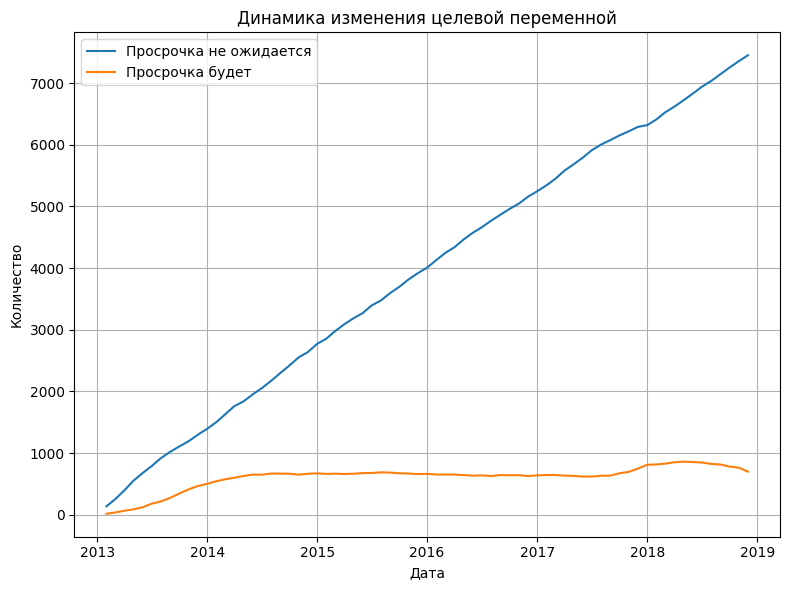

In [10]:
# Подсчет количества значений в классах пл датам
counts = (
    df.groupby(['date', 'default_awaited'])
      .size()
      .unstack(fill_value=0)
)

counts.columns = ['count_0', 'count_1']
plt.figure(figsize=(8, 6))
plt.plot(counts.index, counts['count_0'], label='Просрочка не ожидается')
plt.plot(counts.index, counts['count_1'], label='Просрочка будет')

plt.xlabel('Дата')
plt.ylabel('Количество')
plt.title('Динамика изменения целевой переменной')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

- Классы несбалансированы, дисбаланс увеличивается со временем из-за того, что количество кредитов растет линейно, а количество просрочек сначала медленно растёт, а затем остается примерно на одном уровне. Вероятно, это связано с тем, что датасет содержит данные о клиентах, которые уже выплатили кредит. В этом случае очень важным может оказаться признак времени, прошедшего с регистрации клиента.

### 2.1. Исследование распределения дискретных признаков
- Построим диаграммы распределения дискретных признаков и целевой переменной.

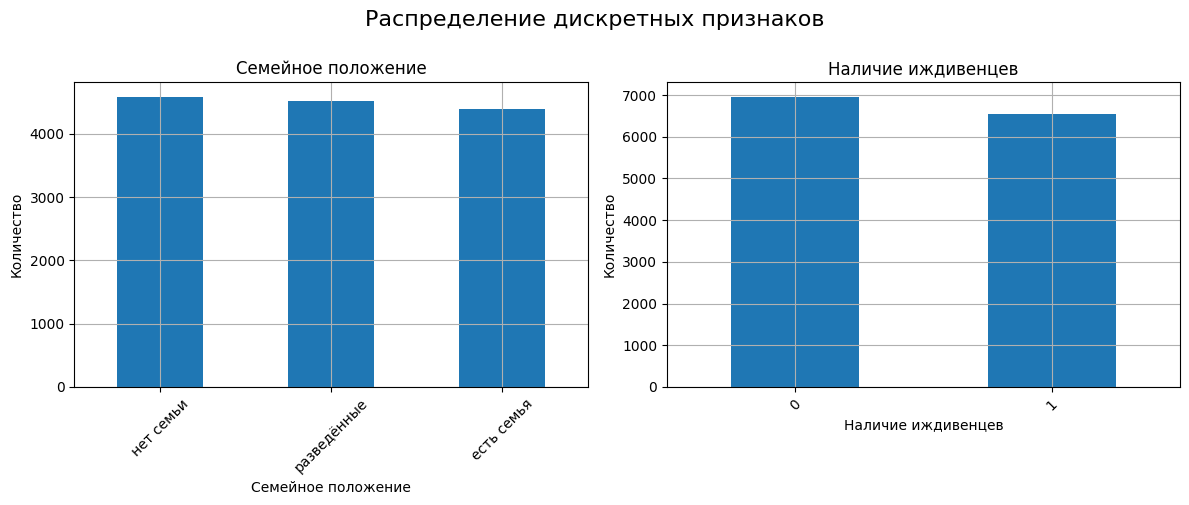

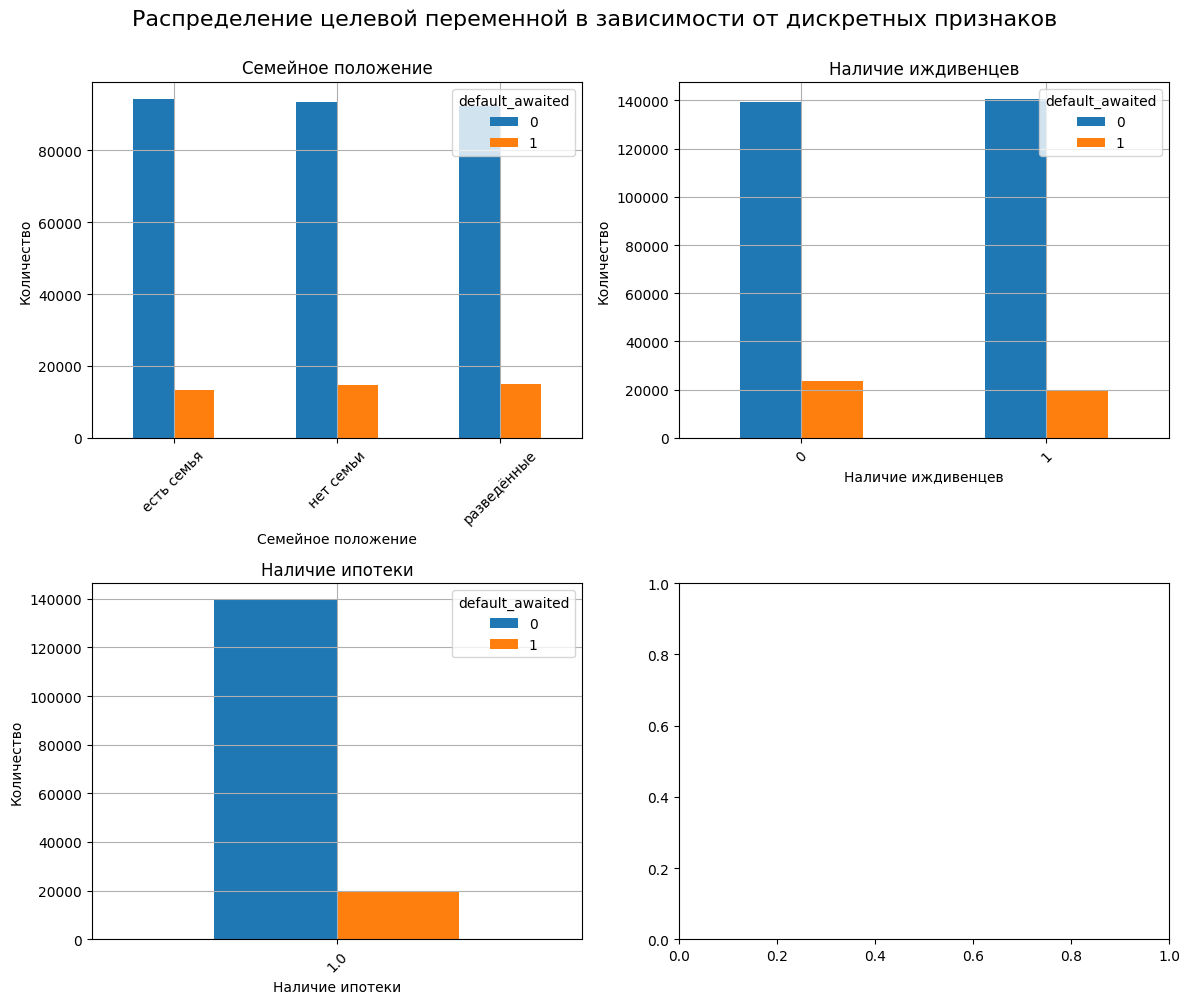

In [11]:
barplot_desc = [
    {"data": datasets['client_description']['семейное_положение'].value_counts(),
     "title": "Семейное положение", "xlabel": "Семейное положение", "ylabel": "Количество", "rot": 45},
    {"data": datasets['client_description']['наличие_иждивенцев'].value_counts(),
     "title": "Наличие иждивенцев", "xlabel": "Наличие иждивенцев", "ylabel": "Количество", "rot": 45}
]

barplot_desc2 = [
    {"data": df.groupby('семейное_положение')[target].value_counts().unstack(fill_value=0),
     "title": "Семейное положение", "xlabel": "Семейное положение", "ylabel": "Количество", "rot": 45},
    {"data": df.groupby('наличие_иждивенцев')[target].value_counts().unstack(fill_value=0),
     "title": "Наличие иждивенцев", "xlabel": "Наличие иждивенцев", "ylabel": "Количество", "rot": 45},
    {"data": df.groupby('наличие_ипотеки')[target].value_counts().unstack(fill_value=0),
     "title": "Наличие ипотеки", "xlabel": "Наличие ипотеки", "ylabel": "Количество", "rot": 45},
]

show_barplot_grid(barplot_desc, "Распределение дискретных признаков")
show_barplot_grid(barplot_desc2, "Распределение целевой переменной в зависимости от дискретных признаков")


- Распределение дискретных признаков близко к равномерному
- Наличие иждивенцев, семьи и ипотеки снижает риск просрочки.

### 2.2. Исследование распределения числовых признаков
- Построим диаграммы распределения числовых признаков клиента по отдельности:

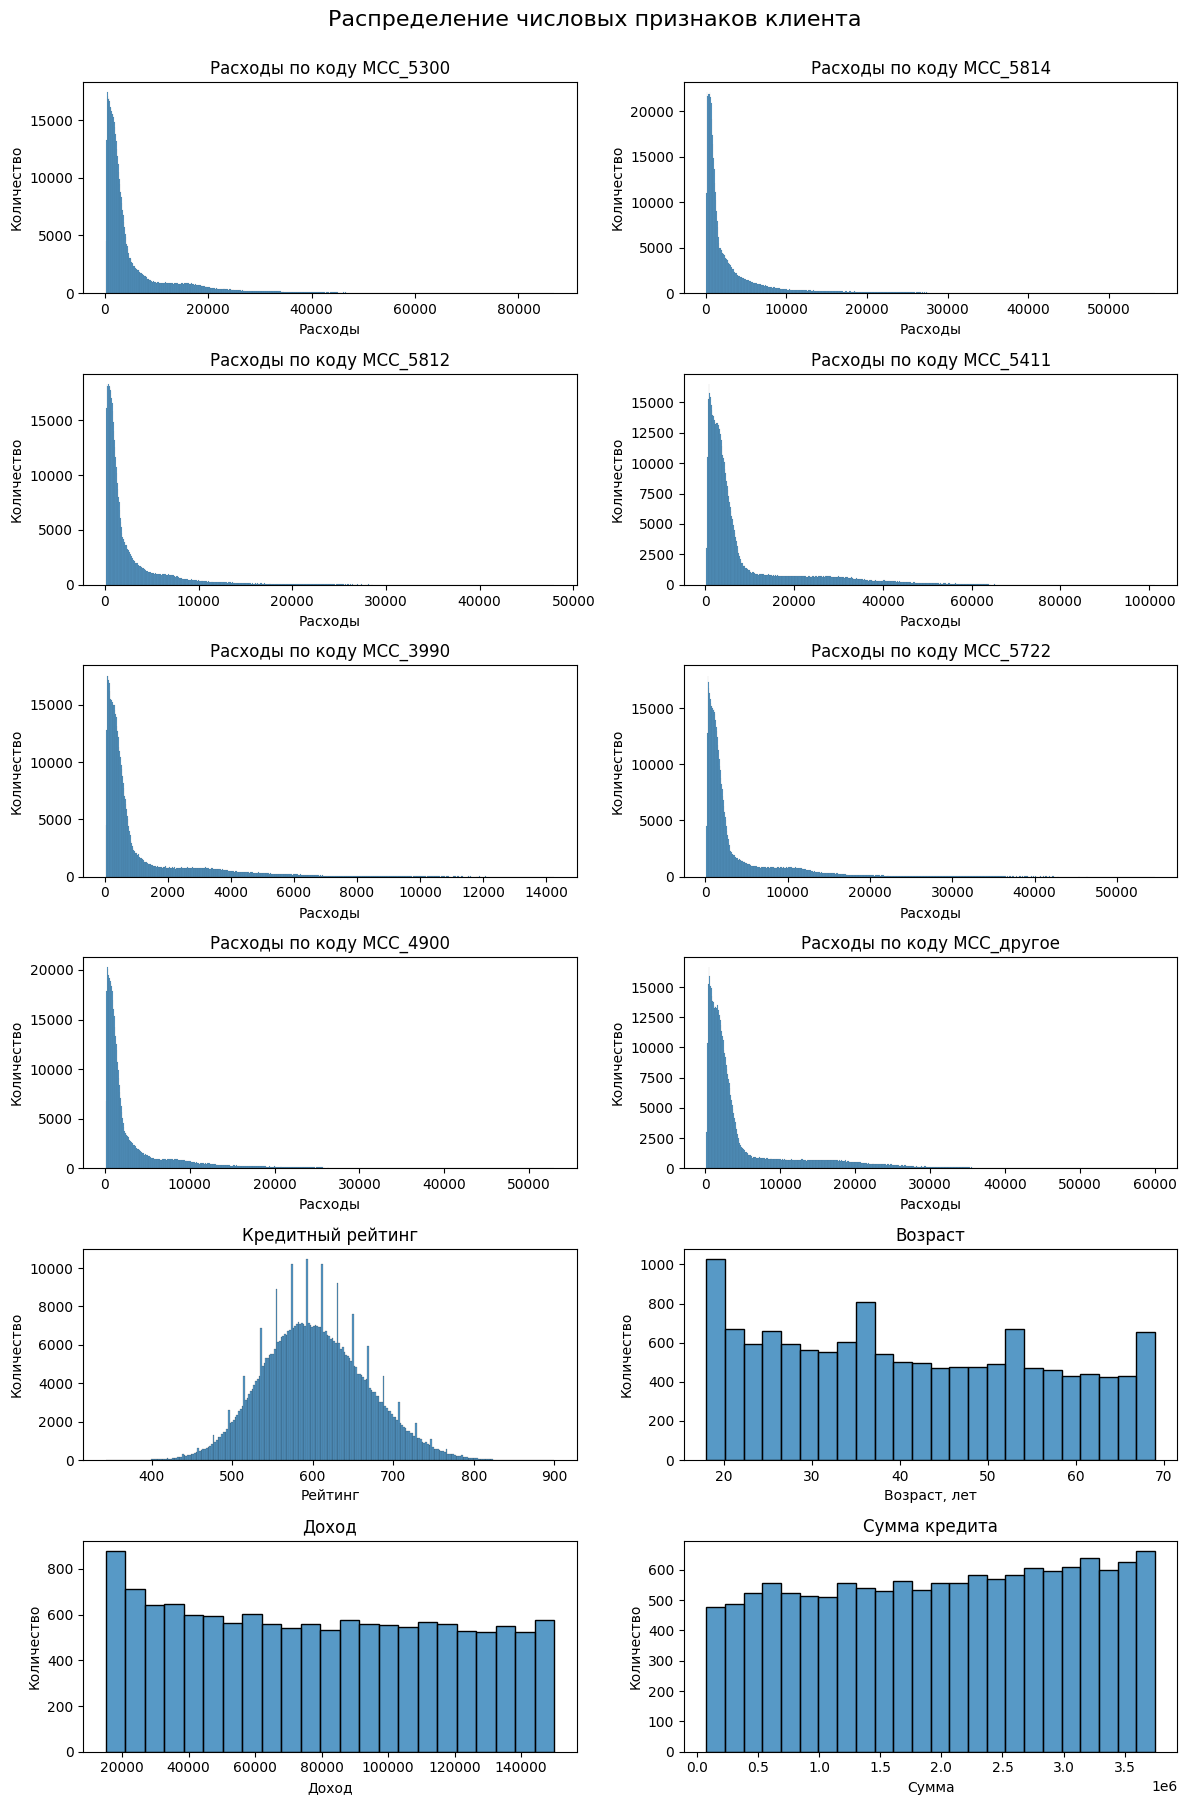

In [12]:
num_features_desc = {
    'MCC_5300': {'data': datasets['transactions'], 'title': "Расходы по коду MCC_5300", 'xlabel': "Расходы"},
    'MCC_5814': {'data': datasets['transactions'], 'title': "Расходы по коду MCC_5814", 'xlabel': "Расходы"},
    'MCC_5812': {'data': datasets['transactions'], 'title': "Расходы по коду MCC_5812", 'xlabel': "Расходы"},
    'MCC_5411': {'data': datasets['transactions'], 'title': "Расходы по коду MCC_5411", 'xlabel': "Расходы"},
    'MCC_3990': {'data': datasets['transactions'], 'title': "Расходы по коду MCC_3990", 'xlabel': "Расходы"},
    'MCC_5722': {'data': datasets['transactions'], 'title': "Расходы по коду MCC_5722", 'xlabel': "Расходы"},
    'MCC_4900': {'data': datasets['transactions'], 'title': "Расходы по коду MCC_4900", 'xlabel': "Расходы"},
    'MCC_другое': {'data': datasets['transactions'], 'title': "Расходы по коду MCC_другое", 'xlabel': "Расходы"},
    'кредитный_рейтинг': {'data': datasets['credit_rating'], 'title': "Кредитный рейтинг", 'xlabel': "Рейтинг"},
    'возраст': {'data': datasets['client_description'], 'title': "Возраст", 'xlabel': "Возраст, лет"},
    'доход': {'data': datasets['credit_description'], 'title': "Доход", 'xlabel': "Доход"},
    'сумма_кредита': {'data': datasets['credit_description'], 'title': "Сумма кредита", 'xlabel': "Сумма"}
}

show_histogram_grid(num_features_desc, "Распределение числовых признаков клиента")

- Также построим диаграммы распределения признаков в совокупности с целевой переменной:

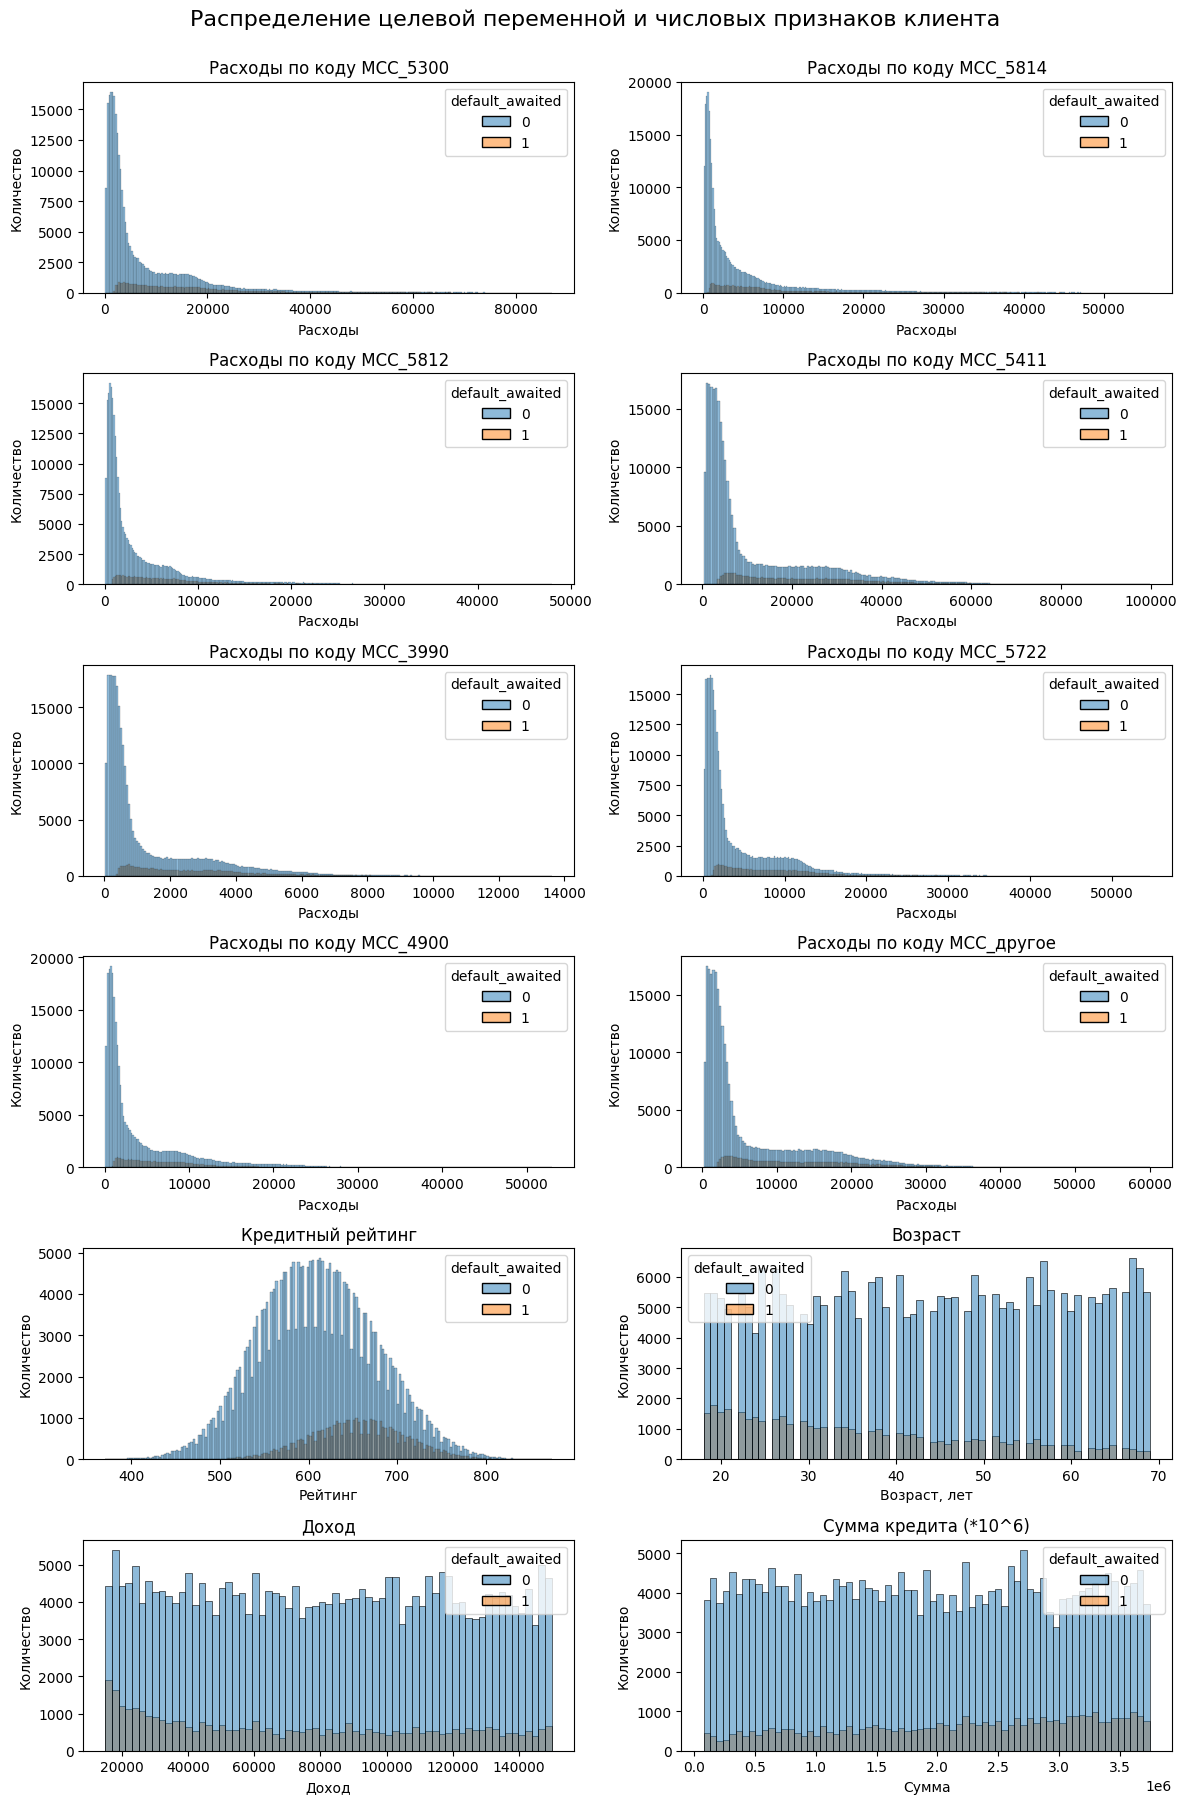

In [13]:
num_features_desc2 = {
    'MCC_5300': {'data': df, 'title': "Расходы по коду MCC_5300", 'xlabel': "Расходы"},
    'MCC_5814': {'data': df, 'title': "Расходы по коду MCC_5814", 'xlabel': "Расходы"},
    'MCC_5812': {'data': df, 'title': "Расходы по коду MCC_5812", 'xlabel': "Расходы"},
    'MCC_5411': {'data': df, 'title': "Расходы по коду MCC_5411", 'xlabel': "Расходы"},
    'MCC_3990': {'data': df, 'title': "Расходы по коду MCC_3990", 'xlabel': "Расходы"},
    'MCC_5722': {'data': df, 'title': "Расходы по коду MCC_5722", 'xlabel': "Расходы"},
    'MCC_4900': {'data': df, 'title': "Расходы по коду MCC_4900", 'xlabel': "Расходы"},
    'MCC_другое': {'data': df, 'title': "Расходы по коду MCC_другое", 'xlabel': "Расходы"},
    'кредитный_рейтинг': {'data': df, 'title': "Кредитный рейтинг", 'xlabel': "Рейтинг"},
    'возраст': {'data': df, 'title': "Возраст", 'xlabel': "Возраст, лет"},
    'доход': {'data': df, 'title': "Доход", 'xlabel': "Доход"},
    'сумма_кредита': {'data': df, 'title': "Сумма кредита (*10^6)", 'xlabel': "Сумма"}
}

show_histogram_grid(num_features_desc2, "Распределение целевой переменной и числовых признаков клиента", hue='default_awaited')

- Расходы по кодам имеют сильно скошенное вправо распределение, пик во всех случаях приходится на суммы менее 1000р. Для модели логистической регрессии эти признаки необходимо прологарифмировать.
- Распределения расходов показывают наличие выбросов, однако суммы 80000-100000р. вполне реальны и не являются следствием ошибки, поэтому удалять их нельзя.
- Распределение кредитного рейтинга нормальное симметричное. Пик просрочек наблюдается для клиентов с кредитным рейтингом выше среднего. 
- Распределение возраста равномерное, с увеличением возраста клиентов риск просрочек уменьшается.
- Распределение дохода близко к равномерному, риск просрочки повышается у клиентов с доходом < 30000р. и увеличивается с уменьшением дохода.
- Распределение суммы кредита также близко к равномерному. С ростом суммы кредита растет риск просрочки.

### 2.3. Исследование корреляции признаков и целевой переменной
- Построим тепловую карту корреляции признаков, используя `phik`:

c:\Users\astuser.PATRIARCHIA\Projects\Yandex DS\ds-yandex\.venv\Lib\site-packages\phik\data_quality.py:82: UserWarning: Not enough unique value for variable наличие_ипотеки for analysis 1. Dropping this column
  warnings.warn(


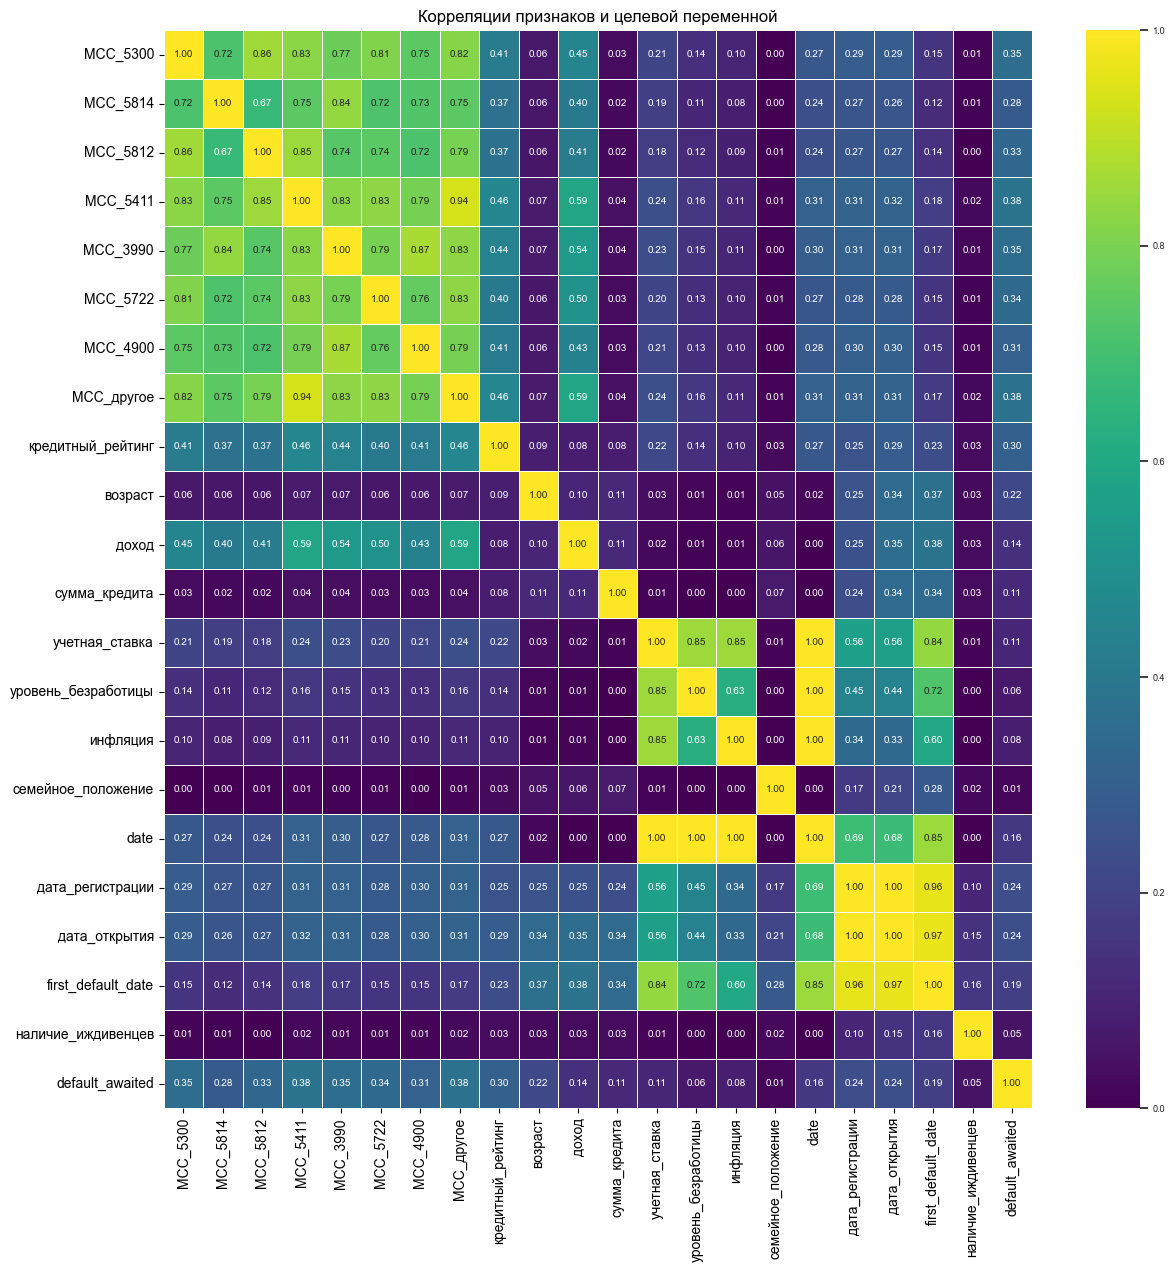

In [14]:
phik_matrix = phik.phik_matrix(df[num_features + cat_features + date_features + bool_features + [target]], 
                               interval_cols=num_features)

draw_heatmap(phik_matrix, "Корреляции признаков и целевой переменной")

- Ожидаемо высока корреляция разных видов расходов друг с другом и с доходами.
- Также ожидаемо высока корреляция временных признаков друг с другом.
- Высокий коэффициент корреляции у макроэкономических признаков - инфляция коррелирует с уровнем безработицы и с учётной ставкой.
- Целевая переменная в наибольшей степени коррелирует с уровнем расходов, возрастом и датой открытия ипотеки.

### 2.4. Выводы
- Классы несбалансированы, дисбаланс увеличивается со временем из-за того, что количество кредитов растет линейно, а количество просрочек сначала медленно растёт, а затем остается примерно на одном уровне.
- Распределение дискретных признаков близко к равномерному
- Наличие иждивенцев, семьи и ипотеки снижает риск просрочки.
- Расходы по кодам имеют сильно скошенное вправо распределение, пик во всех случаях приходится на суммы менее 1000р. Для модели логистической регрессии эти признаки необходимо прологарифмировать.
- Распределения расходов показывают наличие выбросов, однако суммы 80000-100000р. вполне реальны и не являются следствием ошибки, поэтому удалять их нельзя.
- Распределение кредитного рейтинга нормальное симметричное. Пик просрочек наблюдается для клиентов с кредитным рейтингом выше среднего. 
- Распределение возраста равномерное, с увеличением возраста клиентов риск просрочек уменьшается.
- Распределение дохода близко к равномерному, риск просрочки повышается у клиентов с доходом < 30000р. и увеличивается с уменьшением дохода.
- Распределение суммы кредита также близко к равномерному. С ростом суммы кредита растет риск просрочки.
- Высока корреляция разных видов расходов друг с другом и с доходами.
- Высокий коэффициент корреляции у макроэкономических признаков - инфляция коррелирует с уровнем безработицы и с учётной ставкой.
- Целевая переменная в наибольшей степени коррелирует с уровнем расходов, возрастом и датой открытия ипотеки.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Анализ итоговой таблицы для обучения<a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b>  
    
* Верно, что выполняешь проверку на баланс классов! При работе с классификаторами это важный шаг, от него зависят наши дальнейшие действия и результаты.
    
    
* Здорово, что проверяешь данные на наличие информационной избыточности. Информационная избыточность (высокая скоррелированность факторов между собой) для всех моделей создает лишнюю нагрузку без заметного улучшения самой модели, а также смазывает оценку важности (скоррелированные признаки объясняют один и тот же эффект, поэтому важность данного эффекта делится между признаками, из-за чего они теряют позиции в рейтинге).

    
</div>
    
    
<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b>

* Для чего мы проверили наличие дисбаланса? Какие дальнейшие шаги в связи с этим требуются?


* Чтобы убедиться, что архитектурно мы верно объединили таблицы, стоит также проверить дублирование в отношении ключей таблицы - клиент + дата скоринга.

</div>

## 3. Предобработка данных и создание новых признаков
- Необходимо заполнить пропуски в столбцах, относящихся к ипотеке (в случае отсутствия ипотеки).
- Семейное положение закодируем с использованием One-hot encoding.
- Добавим новые признаки: 
    - средний суммарный ежемесячный расход.
    - отношение среднего месячного расхода к доходу.
    - отношение суммы кредита к доходу.
    - количество дней с регистрации.
- Временные признаки, кроме `date` необходимо удалить.
- Для логистической регрессии числовые признаки необходимо масштабировать.

### 3.1. Пайплайны предобработки
- Создадим пайплайны предобработки для заполнения пропусков, добавления новых и модификации существующих признаков:

In [15]:
def feature_engineering(df):
    df = df.copy()
    outcome_codes = [col for col in df.columns if col.startswith('MCC_')]

    # Средний месячный расход по определенным кодам MCC
    df['средний_месячный_расход'] = (df[outcome_codes]
                                    .sum(axis=1)
                                    .expanding()
                                    .mean()
                                    .shift(-1)
                                    .fillna(0))

    # Логарифмирование расходов для уменьшения влияния выбросов
    df[outcome_codes] = df[outcome_codes].apply(lambda x: np.log1p(x))
    
    # Отношение среднего месячного расхода к доходу
    df['расход_к_доходу'] = df['средний_месячный_расход'] / (df['доход'] + 1e-6)

    # Отношение суммы кредита к доходу
    df['кредит_к_доходу'] = df['сумма_кредита'] / (df['доход'] + 1e-6)

    # Количество дней с момента регистрации
    df['дни_с_регистрации'] = ((df['date'] - df['дата_регистрации'].fillna(df['date'])) / 
                           np.timedelta64(1, 'D')).astype(int)
    
    df.drop(columns=['дата_регистрации', 
                     'дата_открытия', 
                     'first_default_date',
                     'ID',
                     'date'], inplace=True)
    return df

num_features_pp = num_features #[line for line in num_features if not line.startswith("MCC")]

lr_preprocess = ImbPipeline(steps=[
    ('feature_engineering', FunctionTransformer(feature_engineering)),
    ('transformer', ColumnTransformer(transformers=[
        ('fillna', SimpleImputer(strategy='constant', fill_value=0), bool_features),
        ('num', StandardScaler(), num_features_pp),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ], remainder='passthrough'))
])
lr_preprocess.set_output(transform='pandas')

rf_preprocess = ImbPipeline(steps=[
    ('feature_engineering', FunctionTransformer(feature_engineering)),
    ('transformer', ColumnTransformer(transformers=[
        ('fillna', SimpleImputer(strategy='constant', fill_value=0), bool_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ], remainder='passthrough'))
])
rf_preprocess.set_output(transform='pandas')

,steps,"[('feature_engineering', ...), ('transformer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function fea...001A95E6FF5E0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... versionadded:: 0.18",None


### 3.2 Исследование добавленных признаков
- Построим диаграммы распределения добавленных признаков:

<class 'pandas.DataFrame'>
Index: 323083 entries, 0 to 424878
Data columns (total 25 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   fillna__наличие_иждивенцев           323083 non-null  float64
 1   fillna__наличие_ипотеки              323083 non-null  float64
 2   cat__семейное_положение_есть семья   323083 non-null  float64
 3   cat__семейное_положение_нет семьи    323083 non-null  float64
 4   cat__семейное_положение_разведённые  323083 non-null  float64
 5   remainder__MCC_5300                  323083 non-null  float64
 6   remainder__MCC_5814                  323083 non-null  float64
 7   remainder__MCC_5812                  323083 non-null  float64
 8   remainder__MCC_5411                  323083 non-null  float64
 9   remainder__MCC_3990                  323083 non-null  float64
 10  remainder__MCC_5722                  323083 non-null  float64
 11  remainder__MCC_4900          

None

,fillna__наличие_иждивенцев,fillna__наличие_ипотеки,cat__семейное_положение_есть семья,cat__семейное_положение_нет семьи,cat__семейное_положение_разведённые,remainder__MCC_5300,remainder__MCC_5814,remainder__MCC_5812,remainder__MCC_5411,remainder__MCC_3990,...,remainder__доход,remainder__сумма_кредита,remainder__учетная_ставка,remainder__уровень_безработицы,remainder__инфляция,remainder__default_awaited,remainder__средний_месячный_расход,remainder__расход_к_доходу,remainder__кредит_к_доходу,remainder__дни_с_регистрации
0,1.0000,0.0000,0.0000,0.0000,1.0000,8.0921,7.1570,7.2855,8.6503,6.4746,...,27035,1960785,5.5000,5.3000,0.4200,0,23213.2550,0.8586,72.5276,31
1,1.0000,0.0000,0.0000,0.0000,1.0000,8.0701,7.8015,7.1968,8.6700,6.9741,...,27035,1960785,5.5000,5.3000,0.8200,0,23748.2767,0.8784,72.5276,61
2,1.0000,0.0000,0.0000,0.0000,1.0000,8.1751,8.3614,7.2894,8.5584,7.0639,...,27035,1960785,5.5000,5.2000,0.1400,0,23742.8475,0.8782,72.5276,92
3,1.0000,0.0000,0.0000,0.0000,1.0000,8.1277,8.4188,7.1408,8.6599,6.8957,...,27035,1960785,5.5000,5.1000,0.2100,0,23607.9860,0.8732,72.5276,123
4,1.0000,0.0000,0.0000,0.0000,1.0000,8.0758,8.3303,7.2486,8.6364,6.4642,...,27035,1960785,5.5000,5.4000,0.5700,0,23991.6650,0.8874,72.5276,153


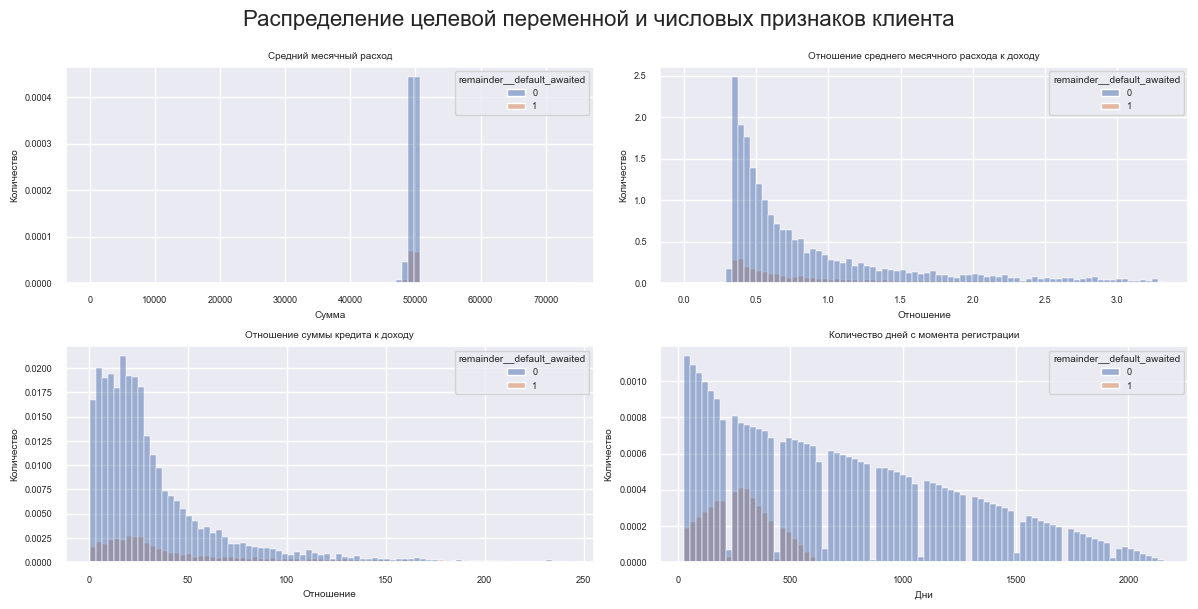

In [16]:
df_pp = rf_preprocess.fit_transform(df)
display(df_pp.info())
display(df_pp.head())
pp_features_desc = {
    'remainder__средний_месячный_расход': {'data': df_pp, 'title': "Средний месячный расход", 'xlabel': "Сумма"},
    'remainder__расход_к_доходу': {'data': df_pp, 'title': "Отношение среднего месячного расхода к доходу", 'xlabel': "Отношение"},
    'remainder__кредит_к_доходу': {'data': df_pp, 'title': "Отношение суммы кредита к доходу", 'xlabel': "Отношение"},
    'remainder__дни_с_регистрации': {'data': df_pp, 'title': "Количество дней с момента регистрации", 'xlabel': "Дни"}
}

show_histogram_grid(pp_features_desc, 
                    "Распределение целевой переменной и числовых признаков клиента", 
                    hue='remainder__default_awaited',
                    stat='density',
                    bins=80)

- Для среднего месячного дохода есть выраженный пик около 50000 р.
- Распределения остальных добавленных признаков правосторонние. Видно, что пик ожидаемых просрочек приходится на 250 дней со дня регистрации, затем к 600 дням их количество падает практически до нуля. Это подтверждает гипотезу о том, что датасеты содержат сведения о клиентах, уже выплативших кредит.

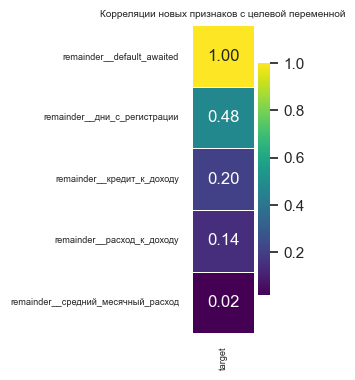

In [17]:
corr_cols = ['remainder__средний_месячный_расход',
            'remainder__расход_к_доходу', 
            'remainder__кредит_к_доходу',
            'remainder__дни_с_регистрации',
            'remainder__default_awaited']

phik_pp = (pd.DataFrame((phik.phik_matrix(df_pp[corr_cols], 
                                        interval_cols=corr_cols)['remainder__default_awaited']
                                        .sort_values(ascending=False)))
            .rename(columns={'remainder__default_awaited': 'target'}))
            
draw_heatmap(phik_pp, "Корреляции новых признаков с целевой переменной", figsize=(1, 4), font_scale=1)

- Корреляция целевой переменной с новым признаком количества дней, прошедших с регистрации, - наибольшая из всех признаков, включая исходные.
- Признаки отношения суммы кредита и расхода к доходу также коррелируют с целевой переменной больше исходных.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Feature engineering<a class="tocSkip"></h4>
    
<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
* Есть интересные идеи!


* Особенно по соотношению расходов / доходов, в поведенческом скоринге оно может быть очень сильным паттерном.

</div>
    
<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> 
    
* Можно еще найти изменения в тратах, которые будут характеризовать поведение. 
    
    
* При создании новых признаков стоит пояснять, почему мы решили их создать, действительно ли, в теории, они могут оказывать эффект на таргет, какая логика за этим скрывается, какой именно эффект?
  
</div>

    
<h4> Пайплайн для подготовки данных <a class="tocSkip"></h4>
<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
* Супер, что не забываем про необходимость цифровизации категориальных данных!
    
    
* Относительно масштабирования. На качество деревянных моделей (дерево, лес, XGBoost, LGBM, CatBoost), на самом деле, оно не окажет никакого влияния, поскольку принцип принятия решения завязан на относительности значений признаков (больше/меньше), а она при масштабировании воздействию не подвергается. Тем не менее масштабирование может немного повлиять на производительность. Но при этом масштабирование важно для методов, основанных на дистанции (KNN, SVM, кластеризация) или вариации (PCA).
    
    С линейными моделями чуть интереснее. На **простую** линейную модель масштабирование, в теории, не окажет никакого влияния на предсказания (однако есть оговорки). Но в некоторых случаях оно все же необходимо.

    <details> <summary> <span style='color:blue' > Развернуть подробнее. </span> </summary>

    Если мы посмотрим на классическое линейное уравнение модели, парметры которого мы оцениваем в процессе обучения, то заметим, что масштабирование никак себя не проявит, поскольку все изменения переменной  просто уйдут в новые коэффициенты:

    $y = \alpha + \beta x$ - без масштабирования
    _____________________________________________________________________________________________________________________

    $y = \alpha_{st} + \beta_{st} \frac{x-mean}{std} = (\alpha_{st} - \frac{\beta_{st}mean}{std}) + (\frac{\beta_{st}}{std}) x$ - со стандартизацией

    При этом $\alpha = (\alpha_{st} - \frac{\beta_{st}mean}{std})$ и $\beta = (\frac{\beta_{st}}{std})$
    _____________________________________________________________________________________________________________________

    $y = \alpha_{mm} + \beta_{mm} \frac{x-min}{max-min} = (\alpha_{mm} - \frac{\beta_{mm}min}{max-min}) + (\frac{\beta_{mm}}{max-min}) x$ - с нормализацией

    При этом $\alpha = (\alpha_{mm} - \frac{\beta_{mm}min}{max-min})$ и $\beta = (\frac{\beta_{mm}}{max-min})$
    _____________________________________________________________________________________________________________________

    Когда же тогда масштабирование необходимо для линейной модели? Ссылки для ознакомления: <a href = 'https://www.listendata.com/2017/04/how-to-standardize-variable-in-regression.html'>тык</a>, <a href = 'https://www.dmitrymakarov.ru/learning/reg/#8-regulyarizatsiya-lineynoy-regressii'>тык</a>. Если кратко резюмировать, то пункты следующие:

    * **Линейные модели с регуляризацией (Ridge, Lasso, Elastic Net)**. Данные модели регулируют те самые коэффициенты, поэтому важно, чтобы масштаб не приводил к тому, что признаки с маленькими значениями будут штафоваться больше (их коэффициенты больше), чем признаки с большими значениями (их коэффициенты меньше). Для Lasso иногда стандартизируют даже бинарные признаки (получаем после OHE), чтобы абсолютно все признаки были в равных условиях. Или же при стандартизации числовых признаков вместно одного стандартного отклонения делят на два, тогда мы получаем примерно равный масштаб с бинарными признаками. Однако острой необходимости в этом нет.

    * **Интерпретация важности признаков.** Сравнивать коэффициенты регрессии по степени влияния на таргет мы можем, только если коэффициенты избавлены от масштаба и приведены к абсолютным значениям.

    * **Разница в масштабах признаков слишком большая.** Мы не можем хранить полностью бесконечные дробные части, поэтому при вычислениях используется некоторое округление. Но из-за того, что признаки имеют слишком разный масштаб, будут сильно различаться и коэффициенты, а значит много чего будет уходить в дробную часть, которую мы частично теряем, начинает страдать точность. Как правило, проблема становится ощутимой, когда разница в масштабах достигает $10^6$.

    * **Используем алгоритм обучения через градиентный спуск (SGD, нейронные сети).** При равномасштабных признаках линии уровня функции потерь имеют округлую форму (вместо элипса при разном масштабе), поэтому алгоритм быстрее и точнее сходится к минимуму (спуск более прямой, а не зигзагообразный).

    * **Используем степени признака (полином) или произведение пары признаков.** Иначе может появляться мультиколлинеарность, что приводит к нестабильности коэффициентов.

  </details>

</div>


<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> 


Линейные модели достаточно критичны к мультиколлинеарности - оценки коэффициентов становятся нестабильными. Несмотря на присутствие встроенной регуляризации в логистической регрессии все же при применении OHE стоит выкидывать одну из категорий.
    
    
</div>

### 3.3. Разделение датасета на выборки
- Разделим датасет на обучающую, калибровочную и тестовую выборки. Для калибровочной и тестовой выборок возьмем последние два года наблюдений:

In [18]:
ind_train = (df['date'].dt.year <= 2016)
ind_cal = (df['date'].dt.year == 2017)
ind_test = (df['date'].dt.year == 2018)

# Сортируем строки по дате
df_sorted = df.sort_values(by='date')

# Группы для кросс-валидации
groups = df_sorted[ind_train]['date'].dt.year

X = df_sorted.drop(columns=[target])
y = df_sorted[target]

# Обучающая выборка
X_train, y_train = X[ind_train], y[ind_train]

# Калибрационная выборка
X_cal, y_cal = X[ind_cal], y[ind_cal]

# Тестовая выборка
X_test, y_test = X[ind_test], y[ind_test]


C:\Users\astuser.PATRIARCHIA\AppData\Local\Temp\ipykernel_2576\2150116618.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  groups = df_sorted[ind_train]['date'].dt.year
C:\Users\astuser.PATRIARCHIA\AppData\Local\Temp\ipykernel_2576\2150116618.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_train, y_train = X[ind_train], y[ind_train]
C:\Users\astuser.PATRIARCHIA\AppData\Local\Temp\ipykernel_2576\2150116618.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_cal, y_cal = X[ind_cal], y[ind_cal]
C:\Users\astuser.PATRIARCHIA\AppData\Local\Temp\ipykernel_2576\2150116618.py:21: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_test, y_test = X[ind_test], y[ind_test]


### Выводы
- Были созданы пайплайны предобработки данных, добавлены новые признаки: 
    - средний суммарный ежемесячный расход.
    - отношение среднего месячного расхода к доходу.
    - отношение суммы кредита к доходу.
    - количество дней с регистрации.
- Датасет разделён на обучающую, калибрационную и тестовую выборки по годам. В калибрационную и тестовую выборки вошли данные за два последних года (2017, 2018). Остальные данные оставлены для обучения.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Формирование выборок<a class="tocSkip"></h4>
    
<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 

При работе с поведенческим скорингом нам важно научиться хорошо предсказывать будущее на основе прошлого. Поскольку данные у нас имеют панельную структуру (наблюдаем во времени сразу нескольких клиентов), нам действительно необходимо позаботиться не только о последовательности данных в тренировочных и оценочных выборок (тренировочный набор должен предшествовать тестовому), но и о том, чтобы месяцы в выборках были изолированы (не попадали сразу в несколько выборок), чтобы не создавались утечки.

</div>
    
<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> 

* В процессе кросс-валидации для `GroupTimeSeriesSplit` рекомендуется также добавить настройку `window_type='expanding'`, чтобы идти по времени с расширением тренировочного окна, как бы накапливая информацию о прошлом. Но вместе с этим нужно будет в том числе сменить настройки параметра `shift_size`. Данный параметр по умолчанию имеет значение 1, но если в качестве групп мы берем месяцы, это приводит к тому, что валидационные фолды будут слишком похожи друг на друга, отличие только в одном месяце, из-за чего теряем преимущества кросс-валидационной оценки. Стоит сдвигать следующий валидационный фолд хотя бы на полгода.
    
    
* Можно провести еще стресс-тест - помимо основного тестирования выделить в тесте новых клиентов (которых ранее модель не видела) и зрелых, первичную информацию о которых модель уже видела в достаточном количестве - чтобы прицельно проверить, как модель работает с теми и с теми. Только тогда уже сейчас на этапе формирования выборок стоит проверить, набирается ли достаточное количество клиентов каждого типа, чтобы была возможность получить устойчивую оценку качества.
    
</div>


## 4. Обучение базовых моделей
### 4.1. Базовые модели логистической регрессии и случайного леса
- Обучим модели логистической регрессии и случайного леса с параметрами по умолчанию на кросс-валидации из 3 фолдов:

In [19]:
def approval_rate_score(y_test, y_pred):
    return np.mean(y_pred == 0)


def default_rate_score(y_test, y_pred):
    approved = (y_pred == 0)
    approved_count = approved.sum()

    if approved_count == 0:
        return 0.0
    defaults_among_approved = np.sum((y_test == 1) & approved)

    return defaults_among_approved / approved_count

def get_scores(y_test, y_pred):
    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred),
        'default_rate': default_rate_score(y_test, y_pred),
        'missed_defaults': 1 - recall_score(y_test, y_pred),
        'approval_rate': approval_rate_score(y_test, y_pred)
    }

def cross_validate_bs(estimator, X, y, cv, groups, prefix = ''):
    accuracy = []
    f1 = []
    precision = []
    recall = []
    roc_auc = []
    default_rate = []
    missed_defaults = []
    approval_rate = []

    for train_ind, val_ind in cv.split(X, groups=groups):
        X_train_cv, y_train_cv = X.iloc[train_ind], y.iloc[train_ind]
        X_val_cv, y_val_cv = X.iloc[val_ind], y.iloc[val_ind]

        estimator.fit(X_train_cv, y_train_cv)
        y_val_pred = estimator.predict(X_val_cv)
        y_val_pred_proba = estimator.predict_proba(X_val_cv)[:, 1]
        accuracy.append(accuracy_score(y_val_cv, y_val_pred))
        f1.append(f1_score(y_val_cv, y_val_pred))
        precision.append(precision_score(y_val_cv, y_val_pred))
        recall.append(recall_score(y_val_cv, y_val_pred))
        roc_auc.append(roc_auc_score(y_val_cv, y_val_pred_proba))
        default_rate.append(default_rate_score(y_val_cv, y_val_pred))
        missed_defaults.append(1 - recall_score(y_val_cv, y_val_pred))
        approval_rate.append(approval_rate_score(y_val_cv, y_val_pred))

    return pd.DataFrame({
        prefix + 'accuracy': accuracy,
        prefix + 'f1': f1,
        prefix + 'precision': precision,
        prefix + 'recall': recall,
        prefix + 'roc_auc': roc_auc,
        prefix + 'default_rate': default_rate,
        prefix + 'missed_defaults': missed_defaults,
        prefix + 'approval_rate': approval_rate
    })

lr_base_cv_args = {
    'train_size': 1,
    'test_size': 1,
    'n_splits': 3,
    'gap_size': 0, 
    'shift_size': 1,
    'window_type': 'rolling'
}

gtscv = GroupTimeSeriesSplit(**lr_base_cv_args)

lr_base_pipeline = Pipeline([
    ('preprocess', lr_preprocess),
    ('model', LogisticRegression(random_state = RANDOM_SEED, solver='liblinear'))
])
display(HTML("<h2>Оценки базовой модели LogisticRegression</h2>"))
lr_base_scores = cross_validate_bs(lr_base_pipeline, X_train, y_train, gtscv, groups)
display(lr_base_scores)

rf_base_pipeline = Pipeline([
    ('preprocess', lr_preprocess),
    ('model', RandomForestClassifier(random_state=RANDOM_SEED))
])
display(HTML("<h2>Оценки базовой модели RandomForestClassifier</h2"))
rf_base_scores = cross_validate_bs(rf_base_pipeline, X_train, y_train, gtscv, groups)
display(rf_base_scores)

,accuracy,f1,precision,recall,roc_auc,default_rate,missed_defaults,approval_rate
0,0.6206,0.2264,0.2180,0.2355,0.5585,0.2418,0.7645,0.7453
1,0.8196,0.1283,0.3351,0.0793,0.5294,0.1604,0.9207,0.9604
2,0.8742,0.0800,0.3839,0.0446,0.7810,0.1187,0.9554,0.9858


,accuracy,f1,precision,recall,roc_auc,default_rate,missed_defaults,approval_rate
0,0.7874,0.3987,0.5980,0.2991,0.7599,0.1873,0.7009,0.8821
1,0.8512,0.3410,0.6583,0.2301,0.8595,0.1368,0.7699,0.9415
2,0.8924,0.3534,0.6692,0.2401,0.9037,0.0974,0.7599,0.9560


- Модели показывают улучшение оценок с увеличением порядкового номера фолда. Это связано с тем, что в датасете с каждым следующим годом количество записей растёт, и обучение проходит успешнее.
- Модель `RandomForestClassifier` показывает лучшие результаты, чем `LogisticRegression`.

### 4.2. Базовые модели с оверсэмплингом
- Добавим в пайплайны оверсэмплинг:

In [20]:
lr_ovs_pipeline = clone(lr_preprocess)
# lr_ovs_pipeline.steps.append(('ovs', SMOTE(k_neighbors=8, random_state=RANDOM_SEED)))
lr_ovs_pipeline.steps.append(('ovs', RandomOverSampler(random_state=RANDOM_SEED)))
lr_ovs_pipeline.steps.append(('model', LogisticRegression(random_state = RANDOM_SEED, solver='liblinear')))

display(HTML("<h2>Оценки модели LogisticRegression с оверсэмплингом RandomOverSampler</h2>"))
lr_ovs_scores = cross_validate_bs(lr_ovs_pipeline, X_train, y_train, gtscv, groups)
display(lr_ovs_scores)

rf_ovs_pipeline = clone(rf_preprocess)
# rf_ovs_pipeline.steps.append(('ovs', SMOTE(k_neighbors=8, random_state=RANDOM_SEED)))
rf_ovs_pipeline.steps.append(('ovs', RandomOverSampler(random_state=RANDOM_SEED)))
rf_ovs_pipeline.steps.append(('model', RandomForestClassifier(random_state = RANDOM_SEED)))

display(HTML("<h2>Оценки модели RandomForestClassifier с оверсэмплингом RandomOverSampler</h2>"))
rf_ovs_scores = cross_validate_bs(rf_ovs_pipeline, X_train, y_train, gtscv, groups)
display(rf_ovs_scores)

,accuracy,f1,precision,recall,roc_auc,default_rate,missed_defaults,approval_rate
0,0.6508,0.5097,0.3809,0.7700,0.7523,0.1036,0.2300,0.5235
1,0.7418,0.5039,0.3713,0.7838,0.8370,0.0559,0.2162,0.6468
2,0.7409,0.4669,0.3121,0.9261,0.8814,0.0142,0.0739,0.6365


,accuracy,f1,precision,recall,roc_auc,default_rate,missed_defaults,approval_rate
0,0.7891,0.3496,0.6398,0.2405,0.7942,0.1964,0.7595,0.9114
1,0.8525,0.3126,0.7095,0.2004,0.8653,0.1404,0.7996,0.9527
2,0.8924,0.3127,0.7186,0.1998,0.9113,0.1015,0.8002,0.9659


### 4.3. Выводы
- Построим общую таблицу метрик всех четырёх моделей со средними значениями по фолдам:

In [21]:
base_scores = pd.DataFrame({
    'LR': lr_base_scores.mean(),
    'LR OVS': lr_ovs_scores.mean(),
    'RF': rf_base_scores.mean(),
    'RF OVS': rf_ovs_scores.mean()
}).T

display(base_scores.style.background_gradient(cmap='viridis', axis=0))

,accuracy,f1,precision,recall,roc_auc,default_rate,missed_defaults,approval_rate
LR,0.771484,0.144882,0.312325,0.119825,0.622982,0.173627,0.880175,0.897154
LR OVS,0.711169,0.493480,0.354773,0.826604,0.823557,0.057906,0.173396,0.602299
RF,0.843657,0.364400,0.641804,0.256447,0.841032,0.140488,0.743553,0.926554
RF OVS,0.844651,0.324928,0.689309,0.213566,0.856946,0.146106,0.786434,0.943362


- Модель `RandomForestClassifier` сильно переобучается - количество пропущенных дефолтов растет от фолда к фолду, а метрика F1 - падает.
- Оверсэмплинг позволяет улучшить метрики, наиболее близкой к целевым показателям стала модель `LogisticClassifier` с оверсэмплингом.
- Тем не менее, ни она из моделей не удовлетворяет требованиям задания по метрике Missed Defaults.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Первичная оценка моделей<a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
* Оценка проведена корректно!


* Здорово, что функционализируешь выполнение повторяющихся действий! Это облегчает визуальную структуру кода и уменьшает влияние человеческого фактора.

</div> 


<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b>     

* В функции бизнес-метрик стоит предусмотреть возможность регулирования порога, чтобы ее можно было переиспользовать в дальнейшем.
    
    
* Было бы интересно также поисследовать иные подходы к балансировке, чтобы подобрать оптимальный вариант - сначала понять, какой из них лучше работает с дефолтными настройками леса, а уже затем дополнительно оптимизировать их. 

    <details> <summary> <span style='color:blue' > Развернуть подробнее. </span> </summary>
    
    При андерсемплинге мы довольно сильно теряем разнообразие объектов мажоритарного класса. Поэтому такой подход обычно лучше работает либо при менее выраженном дисбалансе, либо при большем объеме данных. Иначе модель может начать хуже распознавать представителей основного класса, а ранжирующая способность может заметно проседать. Это будет видно и по метрикам: модель становится значительно более консервативной, сильно снижает approve rate и теряет гибкость.

    При использовании оверсемплинга, наоборот, мы увеличиваем присутствие дефолтов в обучающих данных, из-за чего модель начинает лучше обращать внимание на рискованные объекты. В результате она становится осторожнее: чаще отклоняет пограничных клиентов, жертвуя частью прибыли, но снижая риск пропуска дефолтов. По результатам это буддет выглядеть более оптимальным вариантом - удастся улучшить детект дефолтов без настолько сильной просадки approve rate, как при андерсемплинге.

    При этом сейчас мы скорее выбираем подход, который дает наиболее качественное ранжирование риска дефолта, а не финальный баланс approve/default при конкретном пороге. Поэтому на данном этапе более важны:

    * ranking quality;
    * стабильность метрик;
    * способность модели отделять рискованные объекты от хороших клиентов.

  Финальная настройка баланса между approval rate и default rate уже будет происходить позже - на этапе калибровки и подбора порога.

    Но можно попробовать и промежуточные варианты:

    * mixed over/under sampling;
    * более мягкие коэффициенты балансировки;
    * менее агрессивные настройки oversampling.

  Это может помочь найти более гибкий компромисс между пропущенными дефолтами и одобрениями.

    Также важно учитывать, что при каждом подходе меняется структура обучающих данных, а значит, и оптимальные гиперпараметры модели будут различаться. Подобрать гиперпараметры для одного варианта балансировки и затем использовать их для остальных, скорее всего, не получится.

    </details>


* Стоит отметить, что по бизнес-метрикам логистическая регресиия может казаться лучше, но она менее гибкая и уже показала свой примерный макисмум. В то время как случайный лес довольно сильно зависит от гиперпараметров, поэтому у него еще есть потенциал, его мы пробуем оптимизировать.

</div>


## 5. Подбор гиперпараметров модели `RandomForestClassifier`

### 5.1. Подбор гиперпараметров для `RandomForestClassifier`

In [22]:
def objective_lr(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_samples': trial.suggest_float('max_samples', 0.5, 0.9)
        # 'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])
    }

    rf_pipeline = clone(rf_preprocess)
    # rf_pipeline.steps.append(('ovs', SMOTE(k_neighbors=8, random_state=RANDOM_SEED)))
    # rf_pipeline.steps.append(('us', RandomUnderSampler(sampling_strategy=0.5, random_state=RANDOM_SEED)))
    rf_pipeline.steps.append(('ovs', RandomOverSampler(random_state=RANDOM_SEED)))
    rf_pipeline.steps.append(('model', RandomForestClassifier(random_state=RANDOM_SEED, **params)))

    scores = cross_validate_bs(rf_pipeline, X_train, y_train, gtscv, groups)

    md_score_mean = scores['missed_defaults'].mean()
    trial.report(md_score_mean, step=0)
    if trial.should_prune():
        raise optuna.TrialPruned()

    return md_score_mean

sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)

rf_tree = optuna.create_study(direction="minimize", sampler=sampler) 
rf_tree.optimize(objective_lr, n_trials=15, show_progress_bar=True) 

display(HTML("<h2>Лучшие гиперпараметры:</h2>"))
display(pd.Series(rf_tree.best_params))
display(HTML(f"<h2>Лучшее значение Missed Defaults: </h2>{rf_tree.best_value:8f}"))

[I 2026-06-10 11:36:19,394] A new study created in memory with name: no-name-322de56d-aaf5-4423-aba7-585a8d35673a
Best trial: 0. Best value: 0.310622:   7%|▋         | 1/15 [00:36<08:31, 36.50s/it]

[I 2026-06-10 11:36:55,897] Trial 0 finished with value: 0.310621778202993 and parameters: {'n_estimators': 175, 'max_depth': 15, 'min_samples_leaf': 16, 'min_samples_split': 13, 'max_samples': 0.5624074561769746}. Best is trial 0 with value: 0.310621778202993.


Best trial: 1. Best value: 0.183647:  13%|█▎        | 2/15 [00:52<05:21, 24.71s/it]

[I 2026-06-10 11:37:12,357] Trial 1 finished with value: 0.18364655678261863 and parameters: {'n_estimators': 131, 'max_depth': 5, 'min_samples_leaf': 18, 'min_samples_split': 13, 'max_samples': 0.7832290311184182}. Best is trial 1 with value: 0.18364655678261863.


Best trial: 1. Best value: 0.183647:  20%|██        | 3/15 [01:16<04:50, 24.23s/it]

[I 2026-06-10 11:37:36,023] Trial 2 finished with value: 0.3032067212544446 and parameters: {'n_estimators': 104, 'max_depth': 15, 'min_samples_leaf': 18, 'min_samples_split': 6, 'max_samples': 0.5727299868828403}. Best is trial 1 with value: 0.18364655678261863.


Best trial: 1. Best value: 0.183647:  27%|██▋       | 4/15 [01:36<04:09, 22.71s/it]

[I 2026-06-10 11:37:56,391] Trial 3 finished with value: 0.2248149921315049 and parameters: {'n_estimators': 136, 'max_depth': 8, 'min_samples_leaf': 13, 'min_samples_split': 10, 'max_samples': 0.6164916560792167}. Best is trial 1 with value: 0.18364655678261863.


Best trial: 1. Best value: 0.183647:  33%|███▎      | 5/15 [02:04<04:03, 24.39s/it]

[I 2026-06-10 11:38:23,762] Trial 4 finished with value: 0.1929205591664447 and parameters: {'n_estimators': 222, 'max_depth': 6, 'min_samples_leaf': 9, 'min_samples_split': 8, 'max_samples': 0.6824279936868144}. Best is trial 1 with value: 0.18364655678261863.


Best trial: 1. Best value: 0.183647:  40%|████      | 6/15 [02:32<03:49, 25.53s/it]

[I 2026-06-10 11:38:51,509] Trial 5 finished with value: 0.20804982021539434 and parameters: {'n_estimators': 257, 'max_depth': 7, 'min_samples_leaf': 13, 'min_samples_split': 13, 'max_samples': 0.5185801650879991}. Best is trial 1 with value: 0.18364655678261863.


Best trial: 1. Best value: 0.183647:  47%|████▋     | 7/15 [03:02<03:36, 27.11s/it]

[I 2026-06-10 11:39:21,862] Trial 6 finished with value: 0.19189930028401414 and parameters: {'n_estimators': 222, 'max_depth': 6, 'min_samples_leaf': 6, 'min_samples_split': 20, 'max_samples': 0.8862528132298237}. Best is trial 1 with value: 0.18364655678261863.


Best trial: 1. Best value: 0.183647:  53%|█████▎    | 8/15 [03:40<03:33, 30.43s/it]

[I 2026-06-10 11:39:59,420] Trial 7 pruned. 


Best trial: 1. Best value: 0.183647:  60%|██████    | 9/15 [03:57<02:38, 26.43s/it]

[I 2026-06-10 11:40:17,047] Trial 8 pruned. 


Best trial: 1. Best value: 0.183647:  67%|██████▋   | 10/15 [04:26<02:15, 27.12s/it]

[I 2026-06-10 11:40:45,708] Trial 9 pruned. 


Best trial: 1. Best value: 0.183647:  73%|███████▎  | 11/15 [04:57<01:53, 28.41s/it]

[I 2026-06-10 11:41:17,028] Trial 10 pruned. 


Best trial: 11. Best value: 0.179474:  80%|████████  | 12/15 [05:17<01:17, 25.83s/it]

[I 2026-06-10 11:41:36,978] Trial 11 finished with value: 0.17947446985904977 and parameters: {'n_estimators': 188, 'max_depth': 5, 'min_samples_leaf': 9, 'min_samples_split': 19, 'max_samples': 0.8869993394205519}. Best is trial 11 with value: 0.17947446985904977.


Best trial: 11. Best value: 0.179474:  87%|████████▋ | 13/15 [05:34<00:46, 23.13s/it]

[I 2026-06-10 11:41:53,883] Trial 12 finished with value: 0.1812063237331175 and parameters: {'n_estimators': 165, 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 17, 'max_samples': 0.7882639139995136}. Best is trial 11 with value: 0.17947446985904977.


Best trial: 11. Best value: 0.179474:  93%|█████████▎| 14/15 [05:51<00:21, 21.38s/it]

[I 2026-06-10 11:42:11,227] Trial 13 finished with value: 0.17968638301261444 and parameters: {'n_estimators': 176, 'max_depth': 5, 'min_samples_leaf': 9, 'min_samples_split': 17, 'max_samples': 0.783886832759888}. Best is trial 11 with value: 0.17947446985904977.


Best trial: 11. Best value: 0.179474: 100%|██████████| 15/15 [06:28<00:00, 25.88s/it]

[I 2026-06-10 11:42:47,603] Trial 14 pruned. 


n_estimators        188.0000
max_depth             5.0000
min_samples_leaf      9.0000
min_samples_split    19.0000
max_samples           0.8870
dtype: float64

- Посчитаем метрики модели с лучшими параметрами на кросс-валидации:

In [23]:
best_params =  rf_tree.best_params
# best_params = {'n_estimators': 131, 'max_depth': 5, 'min_samples_leaf': 18, 'min_samples_split': 13, 'max_samples': 0.7832290311184182}
rf_pipeline = clone(rf_preprocess)
rf_pipeline.steps.append(('ovs', RandomOverSampler(random_state=RANDOM_SEED)))
rf_pipeline.steps.append(('model', RandomForestClassifier(random_state=RANDOM_SEED, **best_params)))

rf_best_scores = cross_validate_bs(rf_pipeline, X_train, y_train, gtscv, groups)
display(rf_best_scores)

,accuracy,f1,precision,recall,roc_auc,default_rate,missed_defaults,approval_rate
0,0.6161,0.4936,0.3582,0.7938,0.7371,0.1017,0.2062,0.4776
1,0.7634,0.4948,0.3849,0.6927,0.8325,0.0736,0.3073,0.6989
2,0.6946,0.4389,0.2832,0.9751,0.8825,0.0053,0.0249,0.5782


### 5.2. Выводы
- Полученная модель имеет уровень одобрения кредитов ниже заданного - она слишком осторожна. На каждом следующем фолде метрика recall увеличивается, а precision - уменьшается.
- Для достижения заданных параметров необходима калибровка и настройка порога вероятности положительного класса.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
    
<h4> Подбор гиперпараметров<a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
* По самой оптимизации все супер! 


* Поясню по поводу метрики, почему акцент делаем именно на пропущенных дефолтах. Основная задача нашей модели - хорошо детектить дефолты, делать как можно меньше ошибок в этом плане. Поиск баланса с одобрениями не входит в задачу модели, поэтому ни классические метрики по типу ROC-AUC, ни доля одобрений, ни доля дефолтных одобрений нам не подходят, поскольку будет учитываться в том числе то, сколько мы одобряем. Находить баланс с одобрениями лучше через выбор порога, учитывая соотношение упущенной выгоды и риска потерь. Порог можно двигать в ту или иную сторону, когда мы хотим изменить приоритеты. Стоимость той или иной ошибки может быть разной, в банковской сфере потери обычно обходятся дороже, чем упущенная выгода (лучше заработаем меньше, но сохраним экономический баланс среди текущих клиентов), поэтому гибкость лучше оставить именно на уровне выбора порога.

</div>


<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> 

 
Не хардкодим - не стоит вручную копировать и вставлять значения подобранных гиперпараметров, это лишний риск ввиду человеческого фактора и неудобство в процессе работы над проектом - постоянно придется менять, чтобы испольховалась именно та модель, которую выбрал оптимизатор.

</div>

<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;">
    <font color='4682B4'><u><b>КОММЕНТАРИЙ СТУДЕНТА</b></u></font>
    <br />
    <font color='4682B4'>Убрал хардкод (в первый раз забыл убрать - использовал для того, чтобы не запускать каждый раз оптимизацию, которая занимает много времени).</font>
</div>

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера 2 ✅ <a class="tocSkip"></h3>

## 6. Калибровка модели и подбор порога вероятности положительного класса
### 6.1. Калибровка модели
- Построим калибровочную кривую для полученной модели:

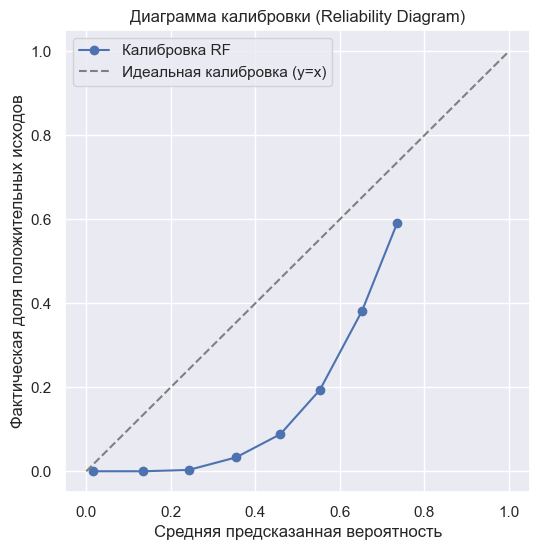

In [24]:
rf_pipeline.fit(X_train, y_train)
y_pred_proba_uncal = rf_pipeline.predict_proba(X_cal)[:, 1]
rf_prob_true, rf_prob_pred = calibration_curve(y_cal, y_pred_proba_uncal, n_bins=10)

# Шаг 3: строим график
def draw_calib_curve(list):
    plt.figure(figsize=(6,6))
    for l in list:
        plt.plot(l[1], l[0], marker='o', label=l[2])

    plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Идеальная калибровка (y=x)')
    plt.xlabel('Средняя предсказанная вероятность')
    plt.ylabel('Фактическая доля положительных исходов')
    plt.title('Диаграмма калибровки (Reliability Diagram)')
    plt.legend()
    plt.grid(True)
    plt.show()

draw_calib_curve([(rf_prob_true, rf_prob_pred, "Калибровка RF")])
rf_brier_uncal = brier_score_loss(y_cal, y_pred_proba_uncal)
display(HTML(f"<h2>Brier score: </h2>{rf_brier_uncal:.4f}"))

- Откалибруем модель с использованием изотонической калибровки на всей калибровочной выборке:

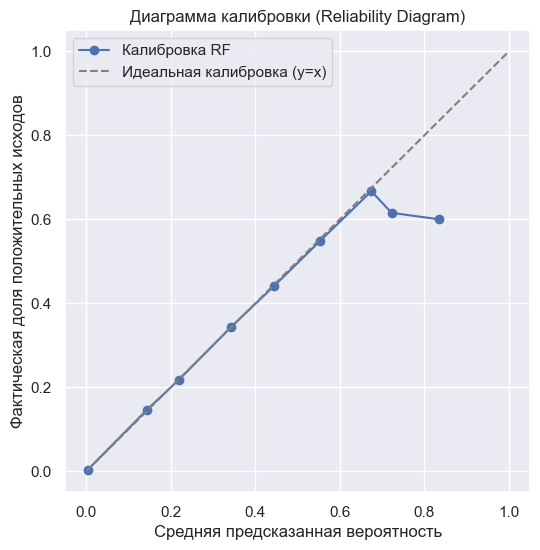

In [25]:
rf_calibrated = CalibratedClassifierCV(
    estimator=FrozenEstimator(rf_pipeline),
    method='isotonic')
rf_calibrated.fit(X_cal, y_cal)

y_pred_proba_cal = rf_calibrated.predict_proba(X_cal)[:, 1]
rf_prob_true_cal, rf_prob_pred_cal = calibration_curve(y_cal, y_pred_proba_cal, n_bins=10)
draw_calib_curve([(rf_prob_true_cal, rf_prob_pred_cal, "Калибровка RF")])
rf_brier_cal = brier_score_loss(y_cal, y_pred_proba_cal)
display(HTML(f"<h2>Brier score: </h2>{rf_brier_cal:.4f}"))

- Калибровка модели улучшилась: кривая стала ближе к идеальной, оценка Бриера уменьшилась до 0.67.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Калибровка модели <a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
* По коду калибровки сейчас все окей!


* Для больших объемов данных и моделей на основе деревьев действительно лучше использовать изотонический подход.
   
    
</div>

<div style="border-radius: 10px" class="alert alert-warning">
    
<b>Рекомендации💡:</b> 

* Чтобы отслеживать переобучаемость калибровки, стоит разделить калибровочную выборку на две части по месяцам - на одной откалибровать, на другой посмотреть результаты калибровки. 

    
* Было бы интересно в учебных целях также взглянуть на бизнес-метрики, изменились ли они? Благоприятные ли это изменения? Или модель стала хуже справляться с нашими основными болевыми точками - неверные одобрения и пропущенные дефолты? Почему так могло произойти? Что теперь нужно с этим сделать?

    При интерпретации стоит иметь в виду, что калибровка не влияет на ранжирующие способности модели, это не способ поднятия ее качества, это лишь способ изменения распределения вероятностей, но их порядок остается прежним.
  
</div>


### 6.2. Подбор порога вероятности положительного класса

- Подберём значение вероятности положительного класса, используя данные кривой Precision/Recall. Из подходящих значений порога выберем то, на котором максимальна метрика F1.

In [26]:
# Кривая Precision-Recall для оценки различных порогов классификации
pc_curve = precision_recall_curve(y_cal, y_pred_proba_cal)

missed_defaults = [(1 - recall_score(y_cal, y_pred_proba_cal >= threshold)) for threshold in pc_curve[2]]
default_rates = [default_rate_score(y_cal, y_pred_proba_cal >= threshold) for threshold in pc_curve[2]]
approval_rates = [approval_rate_score(y_cal, y_pred_proba_cal >= threshold) for threshold in pc_curve[2]]
recall_scores = [recall_score(y_cal, y_pred_proba_cal >= threshold) for threshold in pc_curve[2]]
precision_scores = [precision_score(y_cal, y_pred_proba_cal >= threshold) for threshold in pc_curve[2]]
f1_scores = [f1_score(y_cal, y_pred_proba_cal >= threshold) for threshold in pc_curve[2]]
accuracy_scores = [accuracy_score(y_cal, y_pred_proba_cal >= threshold) for threshold in pc_curve[2]]

threshold_scores = pd.DataFrame({
    'Threshold': pc_curve[2],
    'Missed Defaults': missed_defaults,
    'Default Rate': default_rates,
    'Approval Rate': approval_rates,
    'Recall': recall_scores,
    'Precision': precision_scores,
    'F1': f1_scores,
    'Accuracy': accuracy_scores
})

threshold_table = threshold_scores[(threshold_scores['Missed Defaults'] <= 0.04) &
                         (threshold_scores['Approval Rate'] >= 0.65) &
                         (threshold_scores['Default Rate'] <= 0.02)].sort_values(by='F1', ascending=False)

best_threshold = round(threshold_table.iloc[0]['Threshold'], 3)
display(HTML(f"<h2>Значение порога: </h2>{best_threshold}"))

### 6.3. Выводы
- Исходная модель давала слишком пессимистичные предсказания. Калибровка приблизила предсказываемые вероятности к реальному соотношению классов в калибровочной выборке.
- Был подобран порог вероятности, который, при сохранении целевых показателей в пределах заданных, максимизирует метрику F1.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Поиск порога<a class="tocSkip"></h4>
    
<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b>
    
* Как минимум стоит продемонстрировать, какие значения метрик у нас выходят при выбранном пороге.

  
* Было бы неплохо визуализировать результаты, как менялись метрики при том или ином пороге. Отобразить также наши лимиты. На графике можно обозначить диапазон порогов, которые удовлетворяют установленным лимитам по бизнем-метрикам.


* Можно также отметить, что порог в целом можно двигать в пределах заданных лимитов в зависимости от того, чем мы готовы в той или иной мере пожертвовать - одобрениями или небольшим количеством нераспознанных дефолтов. При подборе порога часто еще используют финансовые показаели, чтобы напрямую регулировать именно баланс прибыли и убытков. Но в плане кредитов это довольно сложно рассчитывается, поэтому реализуем сейчас более простой вариант через метрики.

</div>


# 7. Тестирование и интерпретация модели
### 7.1. Оценка модели на тестовой выборке

In [27]:
y_pred_cal = y_pred_proba_cal >= best_threshold
y_pred_test = rf_calibrated.predict_proba(X_test)[:, 1] >= best_threshold
final_scores_df = pd.DataFrame({
    'Calibration Score': get_scores(y_cal, y_pred_cal),
    'Test Score': get_scores(y_test, y_pred_test),
})
display(final_scores_df.T.style.background_gradient(cmap='viridis', axis=1))

,accuracy,f1,precision,recall,roc_auc,default_rate,missed_defaults,approval_rate
Calibration Score,0.768282,0.454562,0.297899,0.958771,0.852860,0.006143,0.041229,0.675878
Test Score,0.823133,0.526731,0.367010,0.932588,0.871403,0.009722,0.067412,0.731824


- Метрики на тестовой выборке подтверждают качество модели - целевые показатели соблюдены, по accuracy, F1, precision, Approval Rate модель показывает лучшие результаты, чем на калибровочной.

### 7.2. Оценка матриц ошибок
- Построим матрицы ошибок для калибровочной и тестовой выборок:

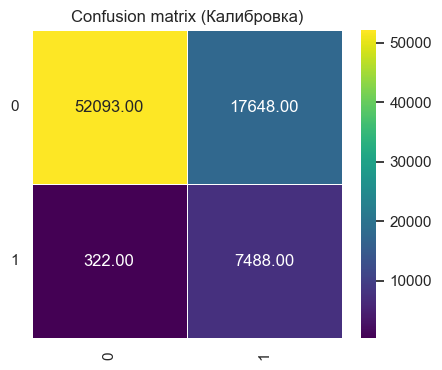

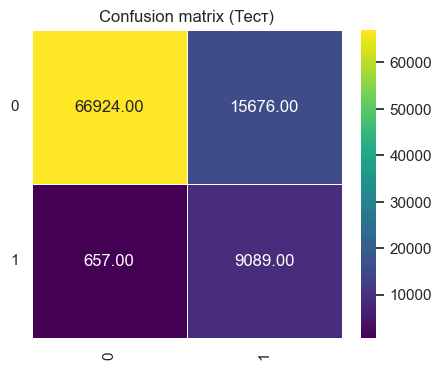

In [28]:
conf_matrix_cal = confusion_matrix(y_cal, y_pred_cal)
draw_heatmap(conf_matrix_cal,
             "Confusion matrix (Калибровка)",
             figsize=(5, 4),
             font_scale=1)

conf_matrix_test = confusion_matrix(y_test, y_pred_test)
draw_heatmap(conf_matrix_test,
             "Confusion matrix (Тест)",
             figsize=(5, 4),
             font_scale=1)

### 7.3. Интерпретация модели - оценка значимости признаков
- Отсортируем признаки по значимости (на основании `feature_importances`):

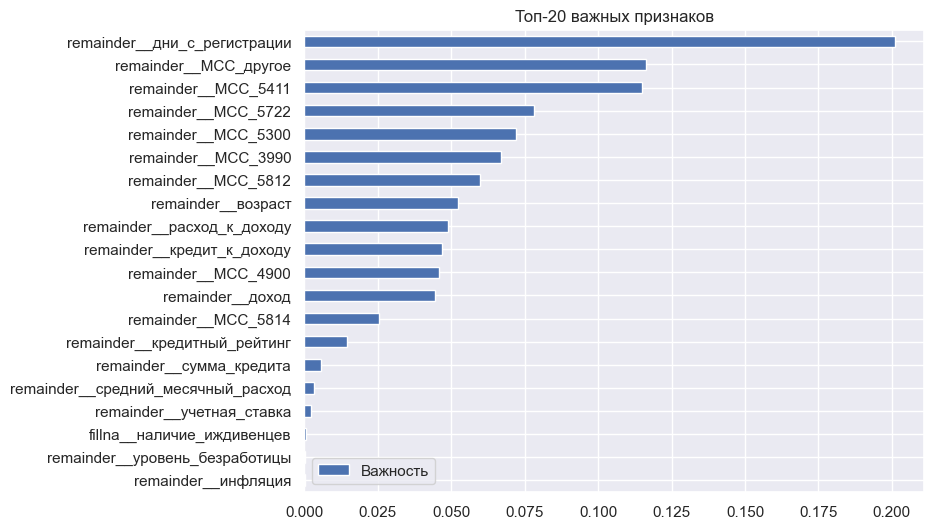

In [29]:
rf_pipeline.named_steps['model'].feature_importances_
feature_names = rf_pipeline.named_steps['transformer'].get_feature_names_out()
feature_importances = pd.DataFrame({'Важность': rf_pipeline.named_steps['model'].feature_importances_}, index=feature_names)
top_features = feature_importances.sort_values('Важность', ascending=True)
top_features.tail(20).plot(kind='barh', figsize=(8, 6), title='Топ-20 важных признаков')
plt.show()

### 7.3. Выводы
- Модель достаточно стабильна и не переучена.
- Полученная модель сответствует предъявленным требованиям по метрикам Approval Rate, Missed Defaults, Default Rate.
- Ошибки модели, в основном, связаны с определением надежных клиентов как рискованных - модель слишком осторожна. Для повышения Approval Rate в ущерб точности выявления дефолтов можно увеличить порог вероятности положительного класса.
- Наиболее важными признаками являются количество дней, поршедших с регистрации, расходы по кодам, возраст, отношения дохода к расходу и суммы кредита к доходу.

## 8. Финальное обучение и сохранение модели
- Обучим модель на объединенной обучающей и калибровочной выборке:

In [30]:
final_pipeline_int = clone(lr_preprocess)
final_pipeline_int.steps.append(('ovs', RandomOverSampler(random_state=RANDOM_SEED)))
final_pipeline_int.steps.append(('model', RandomForestClassifier(random_state=RANDOM_SEED, **best_params)))

X_full = pd.concat([X_train, X_cal])
y_full = pd.concat([y_train, y_cal])
final_pipeline = CalibratedClassifierCV(
    estimator=final_pipeline_int,
    method='isotonic')
final_pipeline.fit(X_full, y_full)
y_final_pred_proba = final_pipeline.predict_proba(X_test)[:, 1]

y_final_pred = y_final_pred_proba >= best_threshold
final_scores_df = pd.DataFrame({
    'Final Test Score': get_scores(y_test, y_final_pred)})
display(final_scores_df.T.style.background_gradient(cmap='viridis', axis=1))

,accuracy,f1,precision,recall,roc_auc,default_rate,missed_defaults,approval_rate
Final Test Score,0.800782,0.514245,0.346215,0.999179,0.888276,0.000125,0.000821,0.695417


- Модель, обученная на расширенной выборке, показывает значительно лучшие результаты и имеет большой запас для увеличения порога Approval Rate без нарушения условий на прочие бизнес-метрики.

- Сохраним пайплайн и проверим корректность сохранения:

In [31]:
PIPELINE_FILE_NAME = "default_prediction.joblib"

try:
    # Сохраним пайплайн
    joblib.dump(final_pipeline, PIPELINE_FILE_NAME)
except Exception as e:
    print("Ошибка сохранения артефактов:", e)
    raise

print("Артефакты сохранены")

# Проверка сохранения и загрузки
try:
    predict_pipeline_loaded = joblib.load(PIPELINE_FILE_NAME)
except Exception as e:
    print("Ошибка загрузки артефактов:", e)
    raise

y_loaded_pred_proba = predict_pipeline_loaded.predict_proba(X_test)[:, 1]
y_loaded_pred = y_loaded_pred_proba >= best_threshold

diff_pred = np.abs(y_final_pred_proba - y_loaded_pred_proba).sum()

if diff_pred == 0.0:
    print("Пайплайн сохранен, проверка прошла успешно.")
else:
    print("Ошибка: ", diff_pred)

Артефакты сохранены
Пайплайн сохранен, проверка прошла успешно.


<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Анализ и фиксирование итоговой модели<a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> Здесь по ходу решения все хорошо!

</div>


<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b>
    

* Выводы не очень интересные. Что полученные результаты обещают бизнесу? Насколько хорошо и стабильно по итогу будет работать модель? Какие есть риски? Все-таки задача направлена на решение конкретной бизнес-проблемы, а не на оторванную от реальности подгонку результатов под определенные значения.


* При фиксировании итоговой модели стоит не просто ее сохранить, но и прописать, какие у нее параметры, какие настройки она имеет, какие факторы она требует на вход, как они должны подготавливаться, какое качество работы от нее можно ожидать на практике, достаточно ли оно для решения бизнес-проблемы, какие есть рекомендации по эксплуатации.

</div>

    
<h4> Анализ важности факторов<a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> Все гуд!

</div>

<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> 

* Важности признаков можно суммировать, чтобы посмотреть общую важность расчленненного признака (при OHE), важность группы скоррелированных факторов или важность факторов определенной сферы.


* Также в оценке важности через встроенный `feature_importance` есть ловушки - данный метод основан на суммарном уменьшении `impurity`, из-за чего будет проявляться смещение в пользу непрерывных признаков и признаков с большим числом уникальных значений. Поэтому между собой разные типы признаков сравнивать по важности не стоит.


* В выводах стоит порассуждать о том, почему те или иные признаки задействовались моделью в большей или меньшей степени.

</div>


## 9. Выводы
- Для анализа и разработки подели предсказания были представлены связанные таблицы в формате CSV. Таблицы были загружены и проанализированы на наличие пропусков и выбросов. Пропусков и ошибочных выбросов не найдено.
- Таблицы были объединены в датасет, рассчитано значение целевой переменной.
- В процессе исследовательского анализа данных были исследованы распределения целевой переменной, категориальных и числовых признаков. Оказалось, что дисбаланс классов целевой переменной растёт со временем, поэтому важным признаком является время, прошедшее с регистрации клиента.
- Было выяснено, что целевая переменная в наибольшей степени коррелирует с уровнем расходов, возрастом и датой открытия ипотеки.
- В датасет были добавлены следующие признаки, рассчитанные с учётом временной структуры данных: 
    - средний суммарный ежемесячный расход.
    - отношение среднего месячного расхода к доходу.
    - отношение суммы кредита к доходу.
    - количество дней с регистрации.
- Датасет был разделен на обучающую, калибрационную и тестовую выборки по периодам (2013-2016 года, 2017 год, 2018 год.). Данные с неполным горизонтом планирования за 2019 год были удалены.
- На обучающей выборке были обучены модели логистической регрессии и случайного леса с параметрами по умолчанию. Обе модели были обучены как на несбалансированных данных, так и на данных, подвергнутых простому случайному оверсэмплингу (`RandomOverSampling`).
- Модели с оверсэмплингом показали лучшие результаты, однако их показатели не удовлетворяли требованиям задания. Модель случайного леса показала значительное переобучение.
- Для модели случайного леса был выполнен подбор гиперпараметров с использованием байесовской оптимизации (библиотека Optuna). Был выбран набор гиперпараметров, минимизирующий метрику Missed Defaults.
- Модель с лучшими гиперпараметрами была откалибрована с использованием изотонической калибровки.
- Порог вероятности определения положительного класса был подобран таким образом, чтобы значения метрик удовлетворяли условиям задания, и метрика F1 была максимальной.
- На тестовой выборке модель показала хорошие результаты, удовлетворяющие сформулированным требованиям; по метикам accuracy, F1, precision, Approval Rate модель показала лучшие результаты, чем на калибровочной выборке.
- Модель была обучена на расширенной выборке, составленной из обучающей и калибрационной выборок. На тестировании она показывает значительно лучшие результаты и имеет большой запас для увеличения порога Approval Rate без нарушения условий на прочие бизнес-метрики.
- Наиболее важными признаками являются количество дней, прошедших с регистрации, расходы по кодам, возраст, отношения дохода к расходу и суммы кредита к доходу.
- Обученный пайплайн был сохранен, проверка сохранения прошла успешно.
- Модель настроена таким образом, чтобы уменьшить риски дефолтов, матрица ошибок показывает, что основной объем ошибок - классификация надежных клиентов как рискованных. Для увеличения количества выдаваемых кредитов можно увеличить порог вероятности положительного класса. Запас, который имеет модель, позволяет это сделать без нарушения основных требований к бизнес-метрикам.

<div style="border:solid #D3D3D3 2px;  border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Итоговые выводы <a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
С задачей справились! Все ключевые моменты отражены, что позволяет быстро ознакомиться с процессом работы и результатом, не вдаваясь в технические детали. 

</div>


<div style="border-radius: 10px" class="alert alert-warning">
    
<b>Рекомендации💡:</b> 
    
* Не хватает конкретики, подкрепления суждений статистикой.
    

* Каков в целом дальнейший жизненный цикл модел? Что будет происходить во время ее эксплуатаци? Отсюда выводим рекомендации.

</div>

<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;">
    <font color='4682B4'><u><b>КОММЕНТАРИЙ СТУДЕНТА</b></u></font>
    <br />
    <font color='4682B4'>Юля, спасибо за подробные комментарии и замечания. Из-за недостатка времени не могу выполнить все рекомендации сейчас, но в будущем обязательно их учту!</font>
</div>

<div style="border:solid Green 2px; border-radius: 10px;  padding: 40px">
<h3>Общий вывод по проекту <a class="tocSkip"></h3>
    
Андрей, спасибо за твой проект! У тебя хорошая работа! В тебе видны зачатки будущего профессионала своего дела :) Давай резюмируем наш с тобой путь, кратко пройдусь по впечатлениям.  
    
**Полнота:** <span style="color:Green;">все требуемые задачи были выполнены!</span>
    
**Корректность:** 

* ✅ <span style="color:Red;">Не каждый год составляет 365 дней, не забываем про високосные, чтобы статистики не смещались.</span>
* ✅ <span style="color:Red;">Предусматриваем потенциальные появления новых просросрочек, новых кредитов и ипотек.</span>
 
**Аналитическая проницательность:** ты верно подмечаешь основные нюансы результатов! Местами можно чуть углубить суждения, фиксировать не только то, что наблюдаем, но и предполагать, почему получилось именно так, что это значит для бизнеса, что с этим делать.
    
**Грамотность кода:** по этому критерию в целом все супер! Используются удобные методы, функции для повторяющихся действий. Не хардкодим.

**Оформление:** им тоже важно не пренебрегать! Оформление тесно связано с удобством восприятия предоставляемой информации и созданием впечатления о работе. Твоя работа оформлена хорошо - выделены разделы, грамотно оформлены графики, ведется последовательный сторителлинг. Так держать! 

<span style="color:Orange;">Ниже прикрепила общие рекомендации на будущее.</span> 

<br/>
    
Рада была помочь ❤️ Критических замечаний не осталось, проект засчитываю. Но обрати внимание на оставшиеся рекомендации - их проработка поможет вывести решение на следующий уровень с точки зрения качества и эффективности.

Поздравляю с завершением такого непростого проекта, дальше - больше! Ценю твои старания, было приятно с тобой поработать 😊

**Желаю огромных успехов в дальнейшем обучении и карьерных достижений!** 🍀

<img src="https://99px.ru/sstorage/86/2015/12/image_86271215043043632690.gif" />


<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Общие рекомендации <a class="tocSkip"></h3>

1. <details> <summary> <span style='color:blue' > Структура, логика и работа с данными (тык) </span> </summary>
    
    * **Глобальный скелет тетрадки**
        * **Что делать:** Строго соблюдать сквозную хронологию разделов исследования:
          1. **Паспорт проекта:** Описание темы, бизнес-цели и технической задачи.
          2. **Инициализация:** Импорт библиотек, фиксация `RANDOM_STATE` при необходимости и загрузка данных в первой ячейке.
          3. **Sanity Check:** Первичный осмотр размера (`.shape`), типов данных (`.info()`) и примеров строк (`.head()`).
          4. **Предобработка (Data Cleaning):** Последовательная очистка типов, пропусков, дубликатов и аномалий в отдельном блоке.
          5. **Модульный EDA:** Разведочный анализ по принципу "один бизнес-вопрос $\rightarrow$ один график $\rightarrow$ промежуточный вывод".
          6. **Моделирование / Статистика** (большие разделы, которые внутри имеют свою подструктуру): Выделенный технический блок для подготовки признаков, проверки гипотез или обучения моделей.
          7. **Бизнес-финал (общий вывод):** Итоговый текстовый раздел без кода с резюме, инсайтами в цифрах и конкретными рекомендациями.
        * **Почему:** Задает жесткую логику повествования, превращая хаотичный код в понятный продукт. Позволяет коллегам быстро ориентироваться в работе, исключает кашу в кодовой базе и гарантирует, что заказчик сразу найдет ответы на свои вопросы в финале.
    
    <br/>
    
    * **Сквозная микро-структура любого раздела (Вступление → Анализ → Резюме)**
        * **Что делать:** Каждый содержательный раздел ноутбука (особенно в блоке EDA) должен быть упакован в строгую трехэтапную структуру:
          1. **Вступление (Постановка контекста):** Короткая Markdown-строка перед кодом. Что мы сейчас будем исследовать, какую гипотезу проверять и на какие вопросы отвечать.
          2. **Содержательная часть (Анализ):** Код, чистые аутпуты и графики, подкрепленные комментариями к логике действий.
          3. **Резюме (Промежуточный вывод):** Финальный текстовый блок в Markdown. Итог раздела, интерпретация причин ("почему так вышло") и бизнес-смысл находки.
        * **Почему:** Защищает ноутбук от превращения в "поток сознания". Без вступления не ясно, зачем написан следующий кусок кода. Без резюме - код зависает в воздухе, а работа выглядит незавершенной.
    
    <br/>
    
    * **Цикличность шагов: "Гипотеза → Действие → Результат → Вывод → ..."**
      * **Что делать:** Каждая содержательная часть строится по одной и той же цепочке: цель / гипотеза → код анализа → интерпретация результата → мостик к следующему шагу. 
      * **Почему:** Работа не должна выглядеть набором случайных действий, она должна читаться как аналитическая статья, где текст плавно ведет читателя сквозь код к выводам.
    
    <br/>
    
    * **Аргументация решений (без очевидных фактов)**
      * **Что делать:** Фиксировать, *почему* выбран конкретный метод обработки пропусков, аномалий или модель. Не писать банальности (например, "функция `mean()` считает среднее").
      * **Почему:** Заказчику важен ход мысли исследователя и обоснованность выбора, а не пересказ документации Python.
    
    <br/>
    
    * **Чистота логики**
      * **Что делать:** Строго разделять этапы обработки и трансформаций и этапы анализа. Необходимо четко понимать, в каком состоянии на данном этапе находятся данные. 
      * **Почему:** Нарушение логики делает результаты анализа недостоверными.

    <br/>
    
    </details>

2. <details> <summary> <span style='color:blue' > Оформление и Markdown (тык) </span> </summary>

    * **Разделение обязанностей: Markdown vs Комментарии**
      * **Что делать:** Смысловой анализ, бизнес-выводы и описание шагов - писать только в Markdown-ячейках. Комментарии внутри кода - использовать только для пояснения нетривиальных алгоритмических решений.
      * **Почему:** Код должен оставаться кодом. Текст в Markdown форматируется, легче читается и формирует структуру проекта.
    
    <br/>
    
    * **Принцип визуального минимализма и единство стиля**
      * **Что делать:** Использовать строгую иерархию заголовков (`#` - крупный раздел, `##` - подраздел), выделять жирным ключевые метрики и выводы. Сохранять один стиль оформления по всей работе.
      * **Почему:** Разнородный стиль отвлекает от сути исследования и выглядит неряшливо.
    
    <br/>
    
    * **Гиперссылки и интерактивное оглавление**
      * **Что делать:** Крупные работы снабжать кликабельным оглавлением со ссылками на теги в Markdown. На внешние источники (ТЗ, статьи, документацию) давать аккуратные гиперссылки вида `[Текст](url)`, а не вставлять голые длинные URL.
      * **Почему:** Упрощает навигацию по объемному ноутбуку.
    
    <br/>
    
    * **Бизнес-метрики vs Технические метрики**
      * **Что делать:** В финальных выводах переводить математические термины на язык денег или бизнес-процессов. Не просто "$R^2 = 0.85$", а "модель ошибается в среднем на X рублей, что позволит сэкономить Y% бюджета".
      * **Почему:** Заказчик оценивает пользу для бизнеса, а не знание высшей математики.

    <br/>
    
    </details>

3. <details> <summary> <span style='color:blue' > Код (тык) </span> </summary>
    
    * **Импорты в строго отведенном месте**
      * **Что делать:** Все библиотеки (`pandas`, `matplotlib` и др.) импортируются **только в первой ячейке** ноутбука. Никаких `import` в середине работы.
      * **Почему:** Сразу видны зависимости проекта. Если у проверяющего нет нужной библиотеки, он узнает об этом на первой секунде, а не через полчаса выполнения кода.
    
    <br/>
    
    * **Строгая фиксация Random State (воспроизводимость)**
      * **Что делать:** В самом первом блоке инициализации фиксировать `SEED` / `RANDOM_STATE` как глобальную константу и передавать её во все функции разбиения данных, сэмплирования и обучения моделей (`train_test_split`, `RandomForest` и т.д.).
      * **Почему:** Без этого при каждом перезапуске тетрадки будут получаться разные метрики и графики. Работа станет невоспроизводимой.
    
    <br/>

    * **Принцип "Одна ячейка - одна атомарная смысловая задача"**
      * **Что делать:** Дробить код. К примеру, в одной ячейке - дубликаты, в другой - пропуски, в третьей - невалидные значения.
      * **Почему:** Упрощает отладку, чтение кода и позволяет запускать отдельные блоки без перезапуска всего проекта.
    
    <br/>
    
    * **Стандарт PEP 8 (Длина строки и отступы)**
      * **Что делать:** Ограничивать длину строки кода до 79 символов. Переносить длинные строки (через скобки или `\`). Использовать 4 пробела для отступов.
      * **Почему:** Избавляет от горизонтального скролла, который сильно утомляет портит читаемость.
    
    <br/>
    
    * **Отказ от хардкода**
      * **Что делать:** Все ключевые параметры, пути к файлам и пороговые значения (например, `UPPER_BOUND = 0.99` для очистки выбросов) выносить в отдельные переменные-константы в начале раздела или ноутбука.
      * **Почему:** Если поменяется бизнес-логика, менять значение нужно будет в одном месте, а не выискивать его по всему коду.
    
    <br/>
    
    * **Осмысленный англоязычный нейминг**
      * **Что делать:** Никакого транслита (`peremennaya`) и безликих названий (`df1`, `data_new`). Использовать понятные имена: `user_profiles`, `clean_transactions`.
      * **Почему:** Позволяет читать код как текст, без необходимости возвращаться к месту объявления переменной.
    
    <br/>
    
    * **Контроль за мусорными переменными и памятью**
      * **Что делать:** Не создавать дубликаты огромных таблиц (`df1`, `df2`, `df_final`). Если датафрейм претерпел сильные изменения, перезаписывать его или удалять старый через `del df_old`.
      * **Почему:** Защищает от переполнения оперативной памяти и падения ядра на больших данных.
    
    <br/>
    
    * **Воспроизводимость кода (линейность)**
      * **Что делать:** Перед сдачей обязательно делать полный перезапуск ноутбука: `Kernel -> Restart & Run All`. 
      * **Почему:** Код должен гарантированно и без ошибок выполняться сверху вниз у любого другого пользователя.
    
    <br/>
    
    * **Контроль за изменением исходных данных (`SettingWithCopyWarning`)**
      * **Что делать:** Избегать цепочечного присваивания (chain indexing) вида `df[df['col'] > 5]['new_col'] = 1`. Использовать `.loc` или явное копирование `.copy()`.
      * **Почему:** Защищает от непредсказуемого изменения исходного датафрейма и избавляет от навязчивых предупреждений Python.
    
    <br/>
    
    </details>

4. <details> <summary> <span style='color:blue' > Аутпуты кодовых ячеек (тык) </span> </summary>

    * **Контроль объема вывода (Head / Tail / Sample)**
      * **Что делать:** Никогда не выводить весь DataFrame целиком. Ограничивать вывод методами `.head()`, `.tail()` или `.sample()`.
      * **Почему:** Тяжелые аутпуты раздувают размер `.ipynb` файла, тормозят браузер и засоряют экран.
    
    <br/>
    
    * **Разделение функций `print()` и `display()`**
      * **Что делать:** Для обычного текста и f-строк использовать `print()`. Для отображения таблиц Pandas - `display()`.
      * **Почему:** `display()` сохраняет красивое интерактивное форматирование среды (Rich Output), делая таблицы читаемыми.
    
    <br/>
    
    * **Форматирование и подпись чисел**
      * **Что делать:** Округлять `float` (например, до 2 знаков через `:.2f`), добавлять единицы измерения (руб., %, сек.). Никаких сырых значений вроде `0.33333333333`.
      * **Почему:** Сырые числа требуют от читателя лишних мысленных усилий для интерпретации.
    
    <br/>
    
    * **Запрет на `print()` для пояснений и выводов**
      * **Что делать:** Текстовые выводы писать строго в Markdown-ячейках, а не генерировать их кодом через `print()`.
      * **Почему:** Вывод через `print` выглядит как небрежно скопированный ответ AI-ассистента и ломает визуальную структуру отчета.
    
    <br/>
    
    * **Подавление системных предупреждений (Warnings)**
      * **Что делать:** Перед сдачей работы исправлять причины возникновения `Warning`. Если это предупреждение библиотеки, которое нельзя обойти, временно заглушать его через `warnings.filterwarnings('ignore')`.
      * **Почему:** Полотна розовых предупреждений от Python между кодом и графиками выглядят грязно и создают ощущение "сырого" решения.
    
    <br/>
    
    * **Опрятность логов циклов и прогресс-баров**
      * **Что делать:** При обучении моделей или парсинге не выводить тысячи строк итераций. Использовать библиотеку `tqdm` для красивой одной строки прогресса.
      * **Почему:** Бесконечный скролл логов убивает читаемость проекта.

    <br/>
    
    </details>

5. <details> <summary> <span style='color:blue' > Визуализация (тык) </span> </summary>
    
    * **"Один график - одна мысль" и минимализм**
      * **Что делать:** Не пытаться уместить на один чарт 10 распределений. Использовать цвет, маркеры и текст только ради смысла, а не "для красоты". Если нужно что-то сравнить - реализуем это на одном графике, а не на двух соседних, так как сравнение - и есть основная задача.
      * **Почему:** Избыточные элементы перегружают восприятие и маскируют главный инсайт.
    
    <br/>
    
    * **Самодостаточность графика**
      * **Что делать:** Обязательно добавлять заголовки и подписи (`title`, `xlabel`, `ylabel`) и легенду (если на графике больше одного цвета / маркера). Подбирать оптимальный размер (`figsize`).
      * **Почему:** График должен быть понятен, даже если его скопируют в презентацию или рабочий чат в отрыве от кода и текста работы.
    
    <br/>
    
    * **Честность масштаба и фокус на данных (Ось Y)**
      * **Что делать:** Для столбчатых диаграмм (`Bar-charts`) и линейных графиков объемов (выручка, пользователи) **всегда начинать ось Y с нуля**. Для диаграмм рассеяния (`Scatter-plots`) и графиков относительных метрик (конверсия, маржинальность, точность моделей) **настраивать масштаб под диапазон данных**, не привязываясь к нулю.
      * **Почему:** В первом случае обрезка оси искусственно раздувает мелкие колебания и пугает бизнес. Во втором случае привязка к нулю "сплющит" график, лишит его детализации и скроет от аналитика реальные тренды и инсайты.
    
    <br/>
    
    * **Читаемость текста и чистый вывод (`plt.show()`)**
      * **Что делать:** Завершать код графика вызовом `plt.show()` (или `;`). Если подписи осей наслаиваются - разворачивать их (`rotation=45`) или менять график на горизонтальный.
      * **Почему:** Убирает мусорные строки технического вывода библиотеки (`<Axes: ...>`) и предотвращает наложение текста.
    
    <br/>
    
    * **Единая палитра для сущностей (смысловой цвет)**
      * **Что делать:** Если на первом графике категории покрашены в определенные цвета (например, "Отток" - красный, "Активные" - синий), эта кодировка должна сохраняться на всех графиках проекта.
      * **Почему:** Мозг читателя привыкает к паттерну. Смена цветов в середине работы запутает аудиторию.
    
    <br/>
    
    * **Сортировка категорий в Bar-charts**
      * **Что делать:** Всегда сортировать столбчатые диаграммы по убыванию или возрастанию целевого значения (кроме естественного порядка, вроде дней недели или месяцев).
      * **Почему:** Забор из хаотичных по высоте столбиков невозможно анализировать глазами. Сортировка сразу подсвечивает лидеров и аутсайдеров. Наличие логического порядка позволяет проследить динамику.
    
    <br/>
    
    * **Правильный выбор типа графика**
      * **Что делать:** Строго соблюдать правила:
        * Не использовать `Pie-chart` (круговую диаграмму), если категорий больше 3–4. Как вариант - малые категории объединить в одну.
        * Не использовать `Line-plot` (линейный график) для несвязанных категориальных данных (только для непрерывных величин или временных рядов).
      * **Почему:** Нарушение этих правил физически искажает восприятие данных человеческим глазом.
    
    <br/>
    
    * **Цветовая доступность и отказ от дефолтных палитр**
      * **Что делать:** Избегать одновременного использования чистого красного и зеленого цветов для контрастных данных (проблема дальтонизма). Использовать современные сбалансированные палитры (например, из библиотеки `seaborn`).
      * **Почему:** Дефолтные кислотные цвета Matplotlib выглядят непрофессионально, а неправильный контраст делает график нечитаемым для части аудитории.

    <br/>
    
    </details>
    
6. <details> <summary> <span style='color:blue' > Культура содержательного анализа (от фактов к инсайтам) (тык) </span> </summary>
    
    * **Постановка задач "от себя"**
      * **Что делать:** Переводить общие требования брифа в плоскость конкретных подзадач анализа внутри ноутбука.
      * **Почему:** Это демонстрирует самостоятельность мышления, а не слепое следование инструкциям.
    
    <br/> 

    * **Запрет на пересказ визуализации (отказ от роли "капитана очевидность")**
      * **Что делать:** Никогда не писать в выводах то, что и так видно глазами. Вместо фразы *"ы видим, что в декабре пик продаж, а в январе - спад"* переходить на уровень причин и бизнес-контекста.
      * **Почему:** Пересказ графиков тратит время читателя и не несет новой информации. Аналитика ценна не констатацией факта, а ответом на вопрос **"Почему так произошло?"**.

    <br/>
    
    * **Правило трех вопросов: "Что? → Почему? → И что с того?"**
      * **Что делать:** Каждое важное наблюдение в данных проводить по трехэтапному фильтру аналитического мышления:
        1. **Что произошло?** (Факт: *"В группе клиентов от 18 до 23 лет отток составляет 40%"*).
        2. **Почему так могло получиться?** (Гипотезы / причины: *"У этой аудитории низкий средний чек, они чувствительны к ценам конкурентов, либо наш интерфейс для них слишком сложный"*).
        3. **И что с того? / Какая польза бизнесу?** (Действие: *"Это критический инсайт. Нам нужно либо запустить для них студенческий тариф, чтобы удержать, либо перестать тратить маркетинг на их привлечение, так как они не окупаются"*).
      * **Почему:** Только третий шаг ("И что с того?") превращает сухие цифры в ценность, за которую бизнес готов платить деньги.

    <br/>
    
    * **Фильтрация инсайтов: "интересно vs бесполезно"**
      * **Что делать:** Оценивать свои находки с точки зрения полезности для принятия решений. 
        * *Бесполезный инсайт:* Очевидная сезонность (например, *"летом продажи мороженого выше"*). Об этом бизнес знает и без аналитика.
        * *Интересный (контринтуитивный) инсайт:* Аномалия или слом шаблона (например, *"мы думали, что скидки привлекают лояльных клиентов, но данные показывают, что они лишь увеличивают отток после окончания акции"*).
      * **Почему:** Если перегрузить итоговый отчет банальными фактами, важные и по-настоящему глубокие инсайты просто потеряются в этом шуме.

    <br/>
    
    * **Поиск причинно-следственных связей (корреляция != причинность)**
      * **Что делать:** Прежде чем делать громкие заявления, проверять альтернативные объяснения. Если продажи выросли одновременно с запуском новой рекламной кампании, нужно проверить, не совпало ли это с праздниками, выплатой зарплат или уходом крупного конкурента.
      * **Почему:** Ложные выводы приводят к неверным бизнес-решениям и потере бюджетов. Хороший аналитик всегда выступает в роли скептика и проверяет скрытые факторы.
    
    <br/>
    
    </details>